In [2]:
!wget https://huggingface.co/neZorinEgor/magnesis/resolve/main/last_weights.zip -O last_weights.zip
!unzip last_weights.zip
!rm last_weights.zip

--2026-06-24 11:23:12--  https://huggingface.co/neZorinEgor/magnesis/resolve/main/last_weights.zip
Resolving huggingface.co (huggingface.co)... 13.249.8.109, 13.249.8.118, 13.249.8.47, ...
Connecting to huggingface.co (huggingface.co)|13.249.8.109|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.aws.cdn.hf.co/xet-bridge-us/6a0f231900d068e89967c55a/9e0a2c74a1f40a088912e65c88427dad5267e93516667fdb925e8ffcf0bfb3a4?X-Xet-Cas-Uid=public&response-content-type=application%2Fzip&user_id=public&response-content-disposition=inline%3B+filename*%3DUTF-8%27%27last_weights.zip%3B+filename%3D%22last_weights.zip%22%3B&Expires=1782274992&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5hd3MuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNmEwZjIzMTkwMGQwNjhlODk5NjdjNTVhLzllMGEyYzc0YTFmNDBhMDg4OTEyZTY1Yzg4NDI3ZGFkNTI2N2U5MzUxNjY2N2ZkYjkyNWU4ZmZjZjBiZmIzYTRcXD9YLVhldC1DYXMtVWlkPXB1YmxpYyZyZXNwb25zZS1jb250ZW50LXR5cGU9YXBwbGljYXRpb24lMkZ6aXAmdXNlcl9pZD1wdWJsaWMmcmVzcG9uc2U

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from torchview import draw_graph

from magnesis import GeomagneticNet, make_dataset

from warnings import filterwarnings
filterwarnings("ignore")

In [4]:
model = GeomagneticNet(model_dir="last_weights", device="cuda")

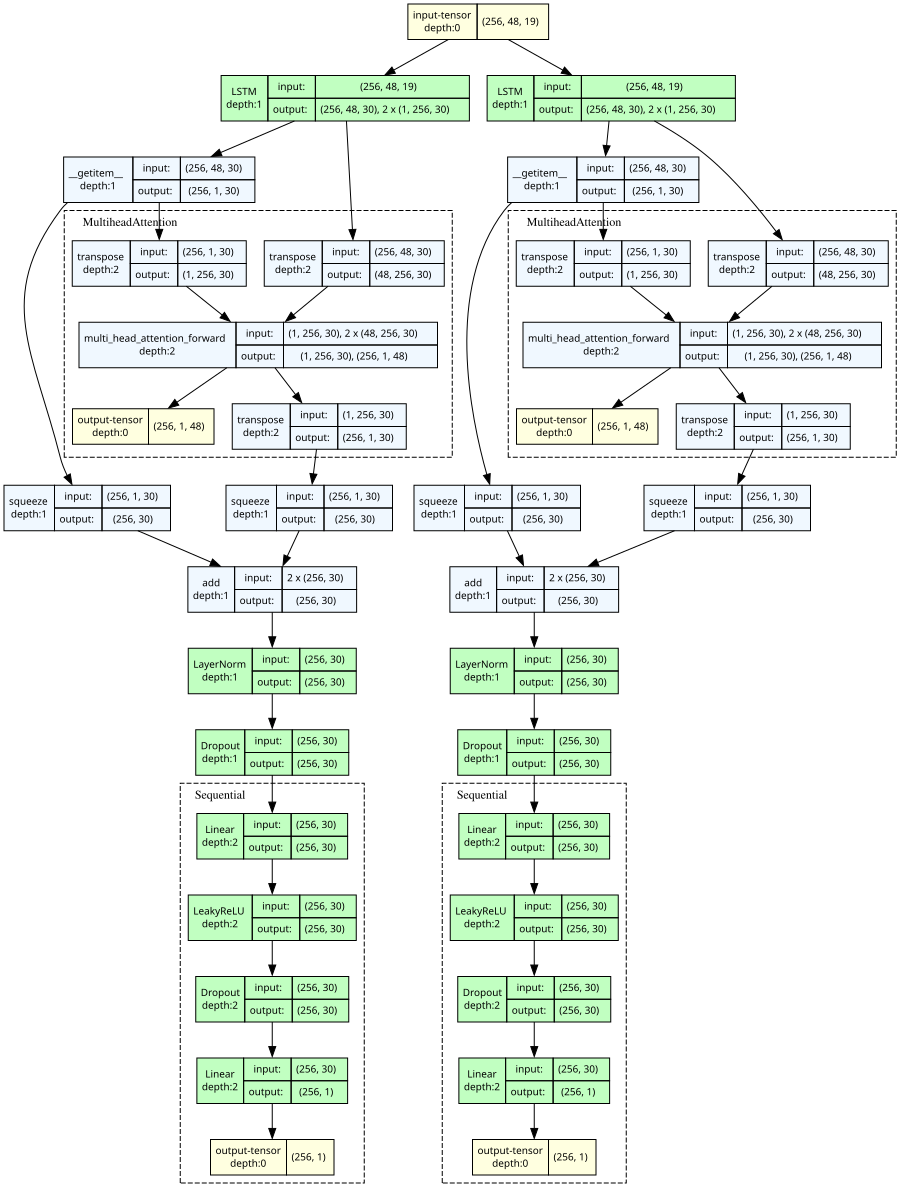

In [5]:
batch_size = 256
X_window_size = 48
n_features = 19
input_size = [batch_size, X_window_size, n_features]
draw_graph(model=model._model, input_size=[256, 48, 19], expand_nested=True).visual_graph

In [4]:
# !mkdir -p data/omni
# !wget -P data/omni https://spdf.gsfc.nasa.gov/pub/data/omni/low_res_omni/omni2_2019.dat
# !wget -P data/omni https://spdf.gsfc.nasa.gov/pub/data/omni/low_res_omni/omni2_2020.dat
# !wget -P data/omni https://spdf.gsfc.nasa.gov/pub/data/omni/low_res_omni/omni2_2021.dat
# !wget -P data/omni https://spdf.gsfc.nasa.gov/pub/data/omni/low_res_omni/omni2_2022.dat
# !wget -P data/omni https://spdf.gsfc.nasa.gov/pub/data/omni/low_res_omni/omni2_2023.dat
# !wget -P data/omni https://spdf.gsfc.nasa.gov/pub/data/omni/low_res_omni/omni2_2024.dat
# !wget -P data/omni https://spdf.gsfc.nasa.gov/pub/data/omni/low_res_omni/omni2_2025.dat

In [21]:
dataset_2019_2025 = make_dataset(omni2_path="./data/omni")

dataset_2019_2025.head(10)

,datetime,Bz_GSM,By_GSM,Bx_GSE,Kp,f10.7,AL,AU,T_proton,Np_density,...,V_Long_GSE,V_Lat_GSE,Dst,AE,hour_sin,hour_cos,day_sin,day_cos,week_sin,week_cos
0,2019-01-01 00:00:00,1.7,3.3,-2.4,10,69.5,-3,25,61944.0,3.9,...,0.2,-1.9,-8,28,0.000000,1.000000e+00,0.017202,0.999852,0.781831,0.62349
1,2019-01-01 01:00:00,-1.0,3.9,0.5,10,69.5,-12,24,59925.0,3.9,...,-0.1,-1.0,-11,36,0.258819,9.659258e-01,0.017202,0.999852,0.781831,0.62349
2,2019-01-01 02:00:00,1.9,3.4,2.7,10,69.5,-24,14,49175.0,4.0,...,0.6,-2.0,-9,38,0.500000,8.660254e-01,0.017202,0.999852,0.781831,0.62349
3,2019-01-01 03:00:00,2.5,4.1,2.8,13,69.5,-4,21,36301.0,4.5,...,0.0,-1.9,-7,25,0.707107,7.071068e-01,0.017202,0.999852,0.781831,0.62349
4,2019-01-01 04:00:00,-0.1,4.6,1.1,13,69.5,-6,34,55764.0,5.2,...,0.2,-1.3,-4,40,0.866025,5.000000e-01,0.017202,0.999852,0.781831,0.62349
5,2019-01-01 05:00:00,-3.4,4.4,-0.9,13,69.5,-32,54,57738.0,4.6,...,0.0,-0.3,-9,86,0.965926,2.588190e-01,0.017202,0.999852,0.781831,0.62349
6,2019-01-01 06:00:00,-3.4,3.5,-1.2,27,69.5,-240,19,50853.0,4.3,...,0.0,0.2,-12,259,1.000000,6.123234e-17,0.017202,0.999852,0.781831,0.62349
7,2019-01-01 07:00:00,-3.2,3.5,-0.5,27,69.5,-259,40,52449.0,4.3,...,-0.1,-0.4,-17,299,0.965926,-2.588190e-01,0.017202,0.999852,0.781831,0.62349
8,2019-01-01 08:00:00,-3.5,3.0,-1.1,27,69.5,-232,60,46433.0,4.7,...,-0.4,0.1,-22,293,0.866025,-5.000000e-01,0.017202,0.999852,0.781831,0.62349
9,2019-01-01 09:00:00,-3.0,2.3,2.3,17,69.5,-222,79,35205.0,4.7,...,0.4,-0.4,-22,300,0.707107,-7.071068e-01,0.017202,0.999852,0.781831,0.62349


In [ ]:
data = dataset_2019_2025.iloc[:100]
plt.plot(data["hour_sin"])
plt.plot(data["hour_cos"])
plt.plot(data["day_sin"])
plt.plot(data["day_cos"])
plt.plot(data["week_sin"])
plt.plot(data["week_cos"])

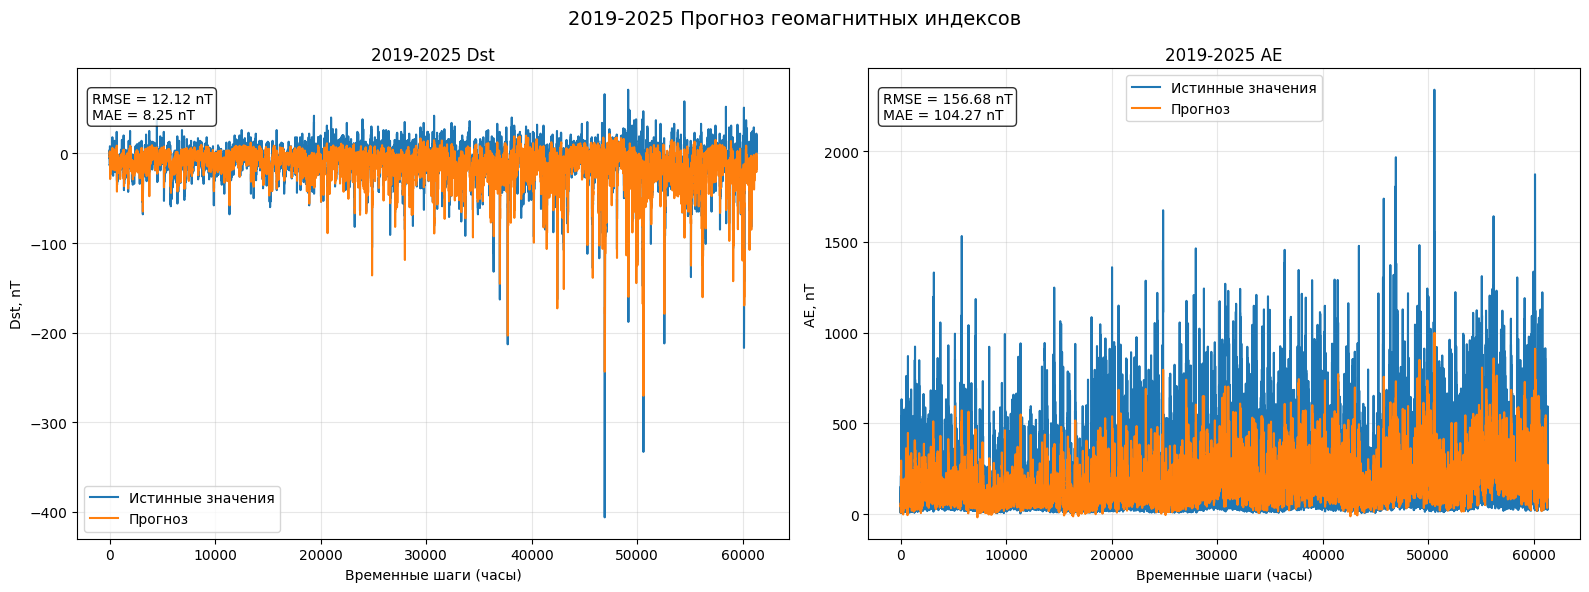

2019-2025 Результаты прогноза
Dst: RMSE = 12.12 nT, MAE = 8.25 nT
AE:  RMSE = 156.68 nT, MAE = 104.27 nT


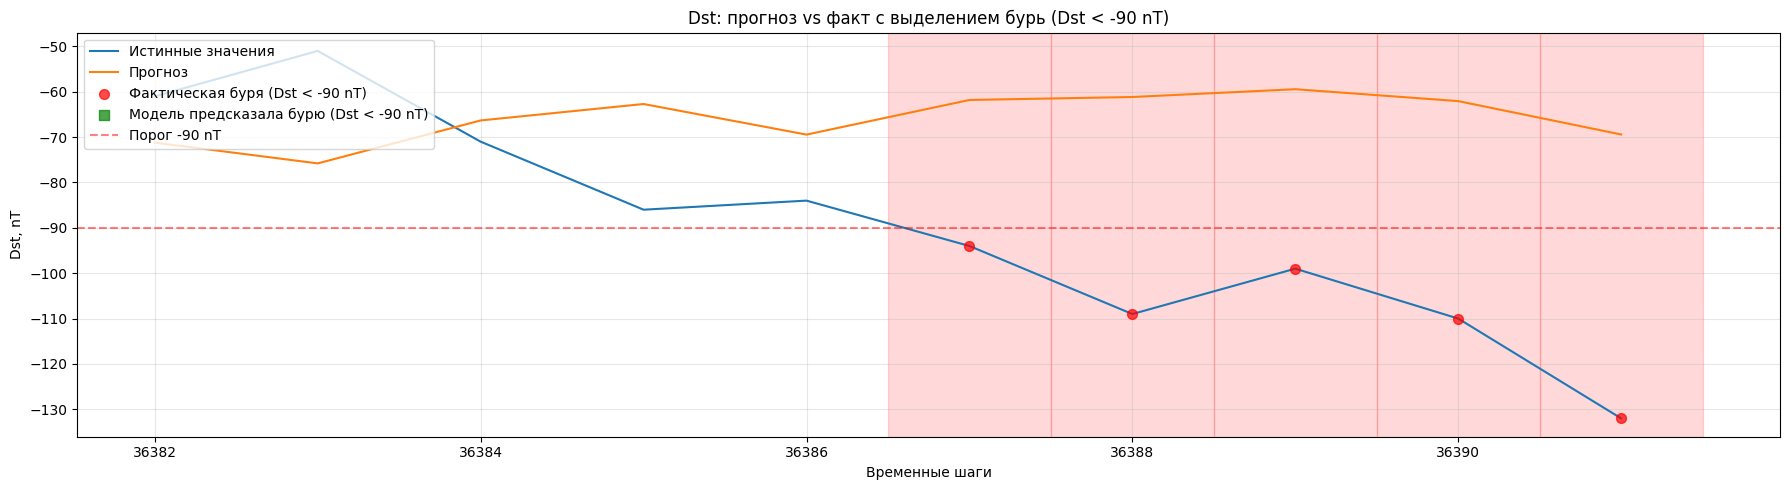

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 5
Всего моментов, когда модель предсказала бурю: 0
Precision: 0.000
Recall: 0.000


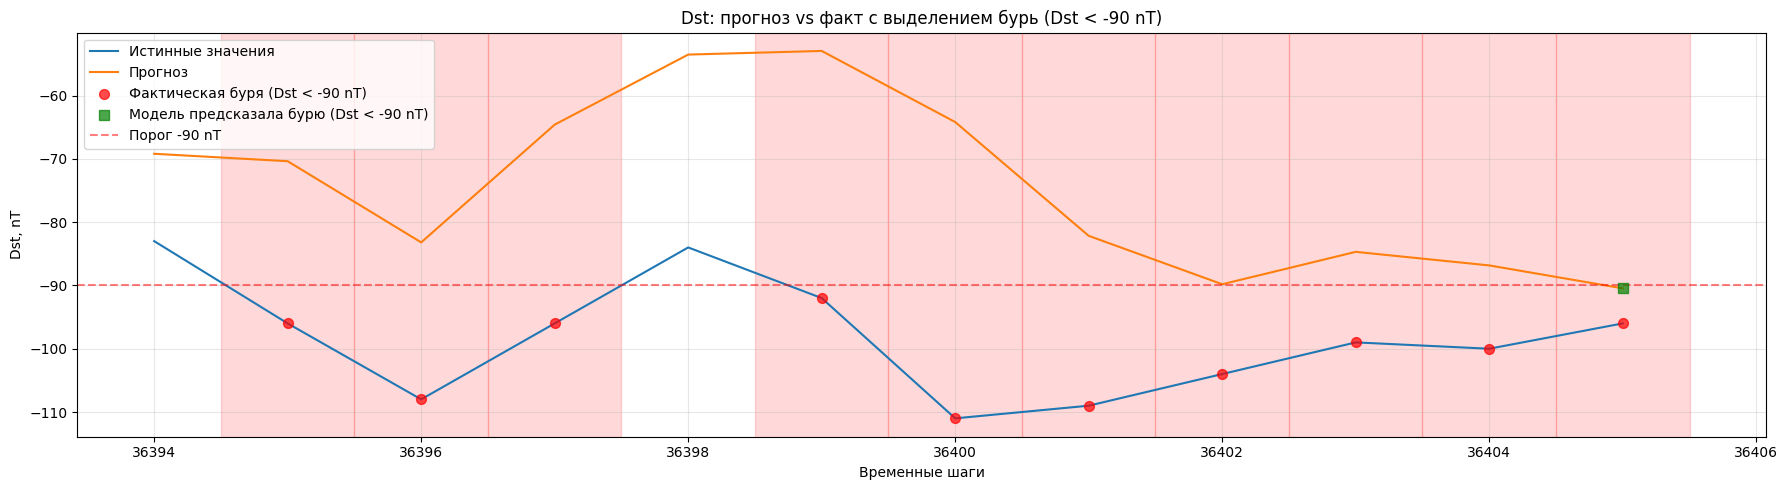

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 10
Всего моментов, когда модель предсказала бурю: 1
Precision: 1.000
Recall: 0.100
F1: 0.182


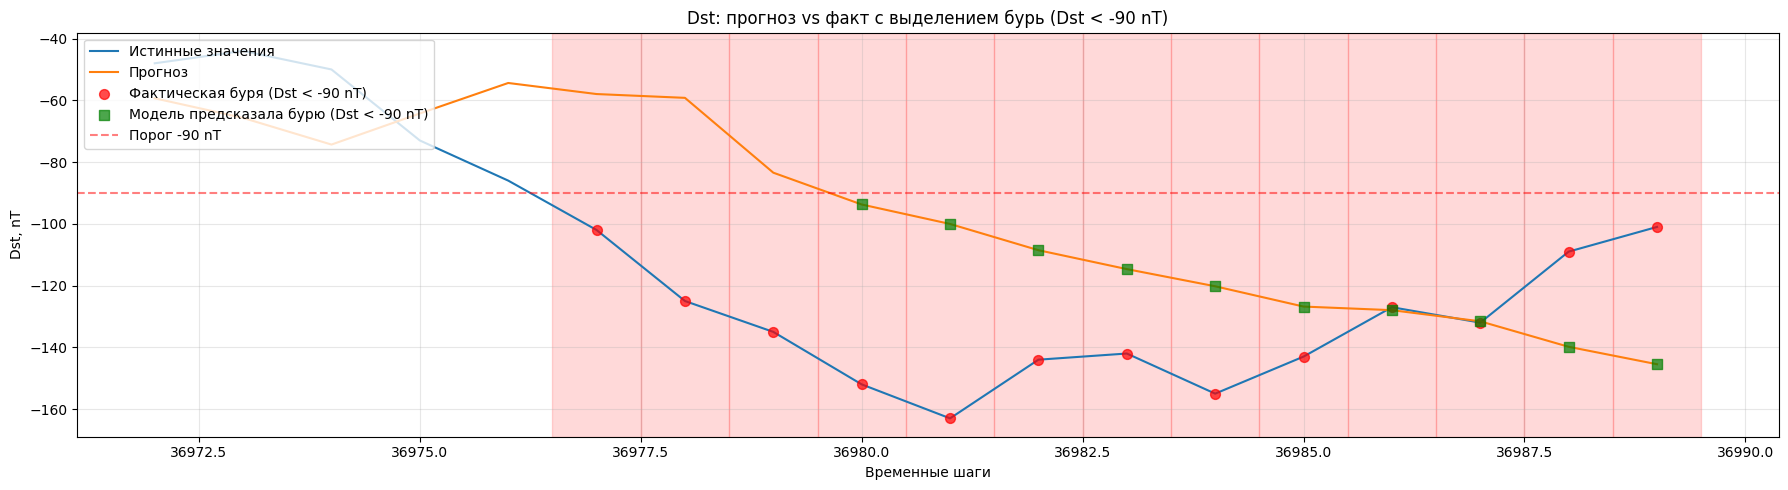

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 13
Всего моментов, когда модель предсказала бурю: 10
Precision: 1.000
Recall: 0.769
F1: 0.870


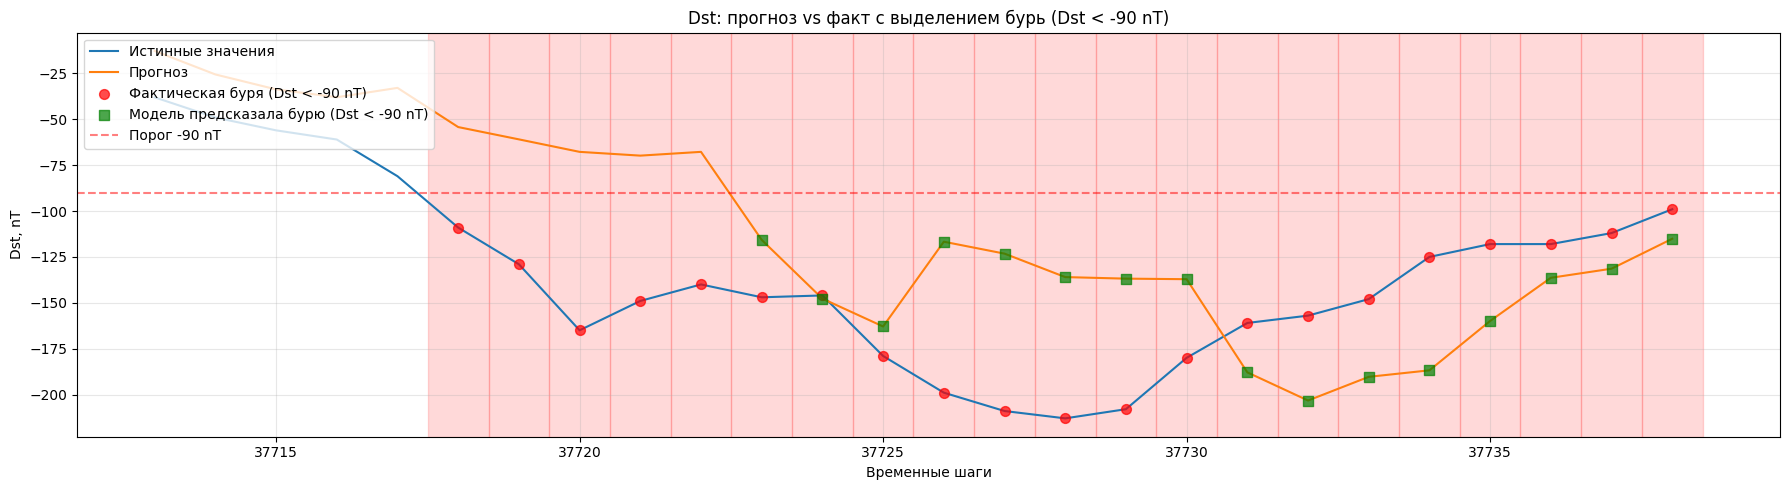

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 21
Всего моментов, когда модель предсказала бурю: 16
Precision: 1.000
Recall: 0.762
F1: 0.865


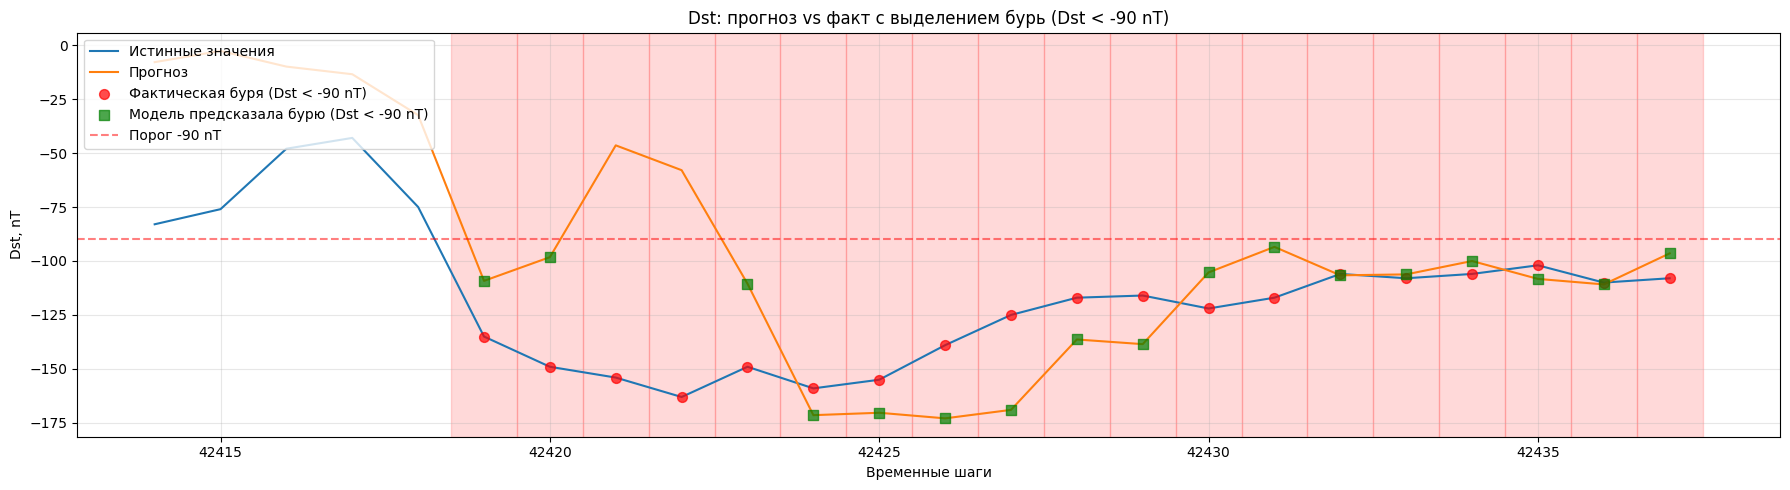

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 19
Всего моментов, когда модель предсказала бурю: 17
Precision: 1.000
Recall: 0.895
F1: 0.944


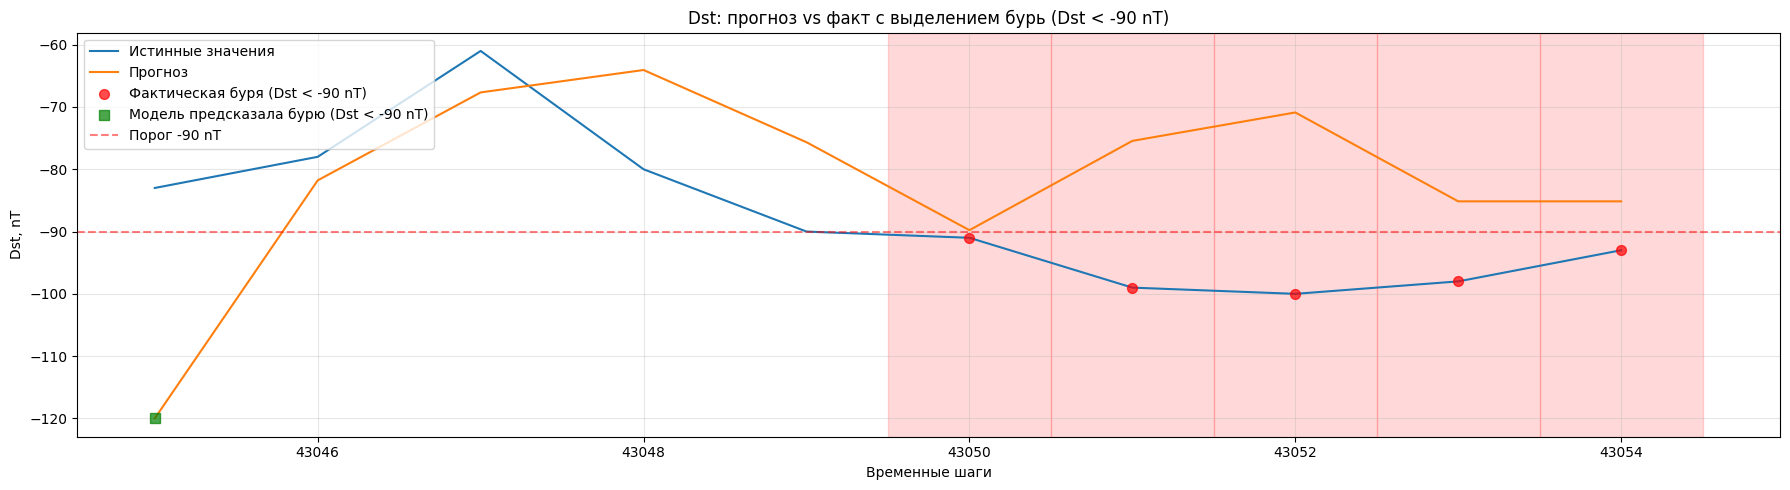

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 5
Всего моментов, когда модель предсказала бурю: 1
Precision: 0.000
Recall: 0.000


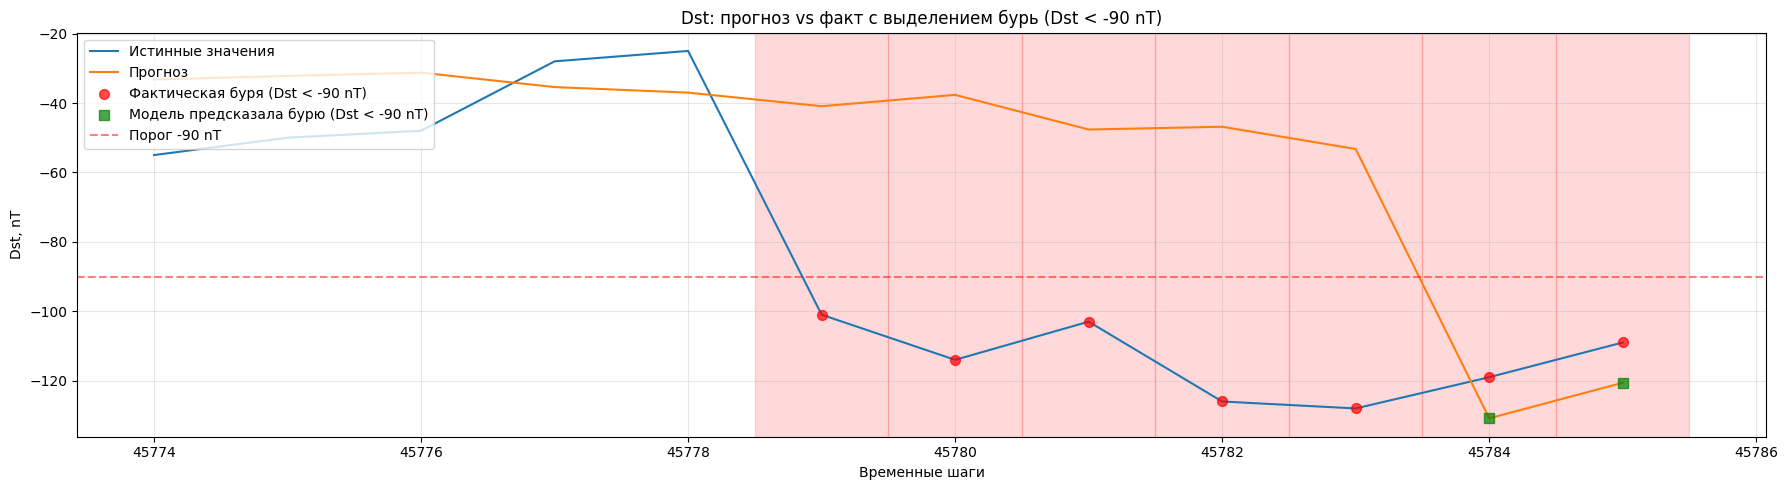

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 7
Всего моментов, когда модель предсказала бурю: 2
Precision: 1.000
Recall: 0.286
F1: 0.444


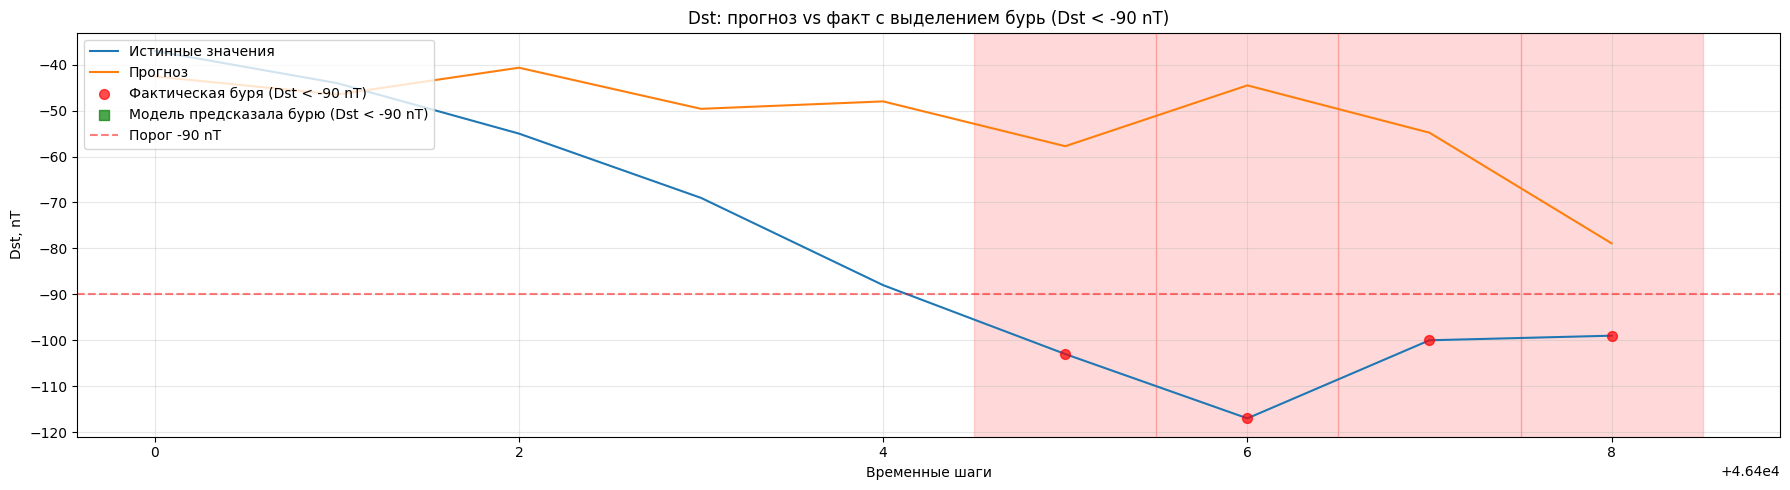

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 4
Всего моментов, когда модель предсказала бурю: 0
Precision: 0.000
Recall: 0.000


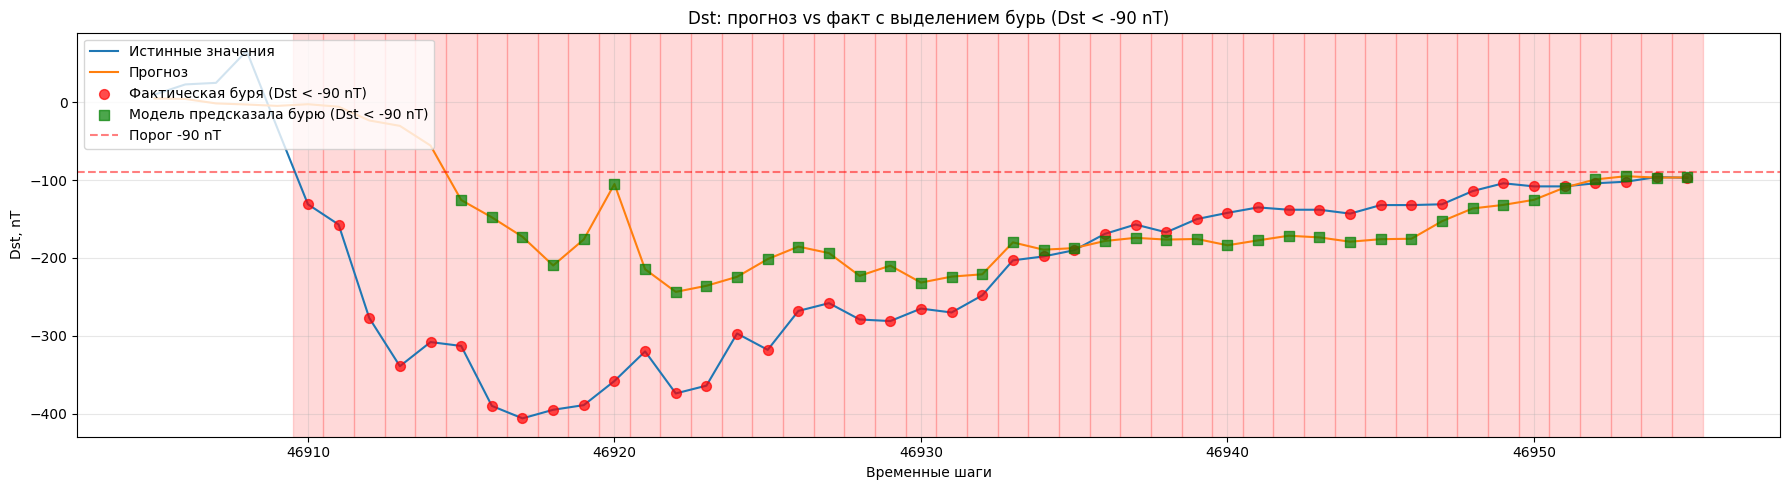

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 46
Всего моментов, когда модель предсказала бурю: 41
Precision: 1.000
Recall: 0.891
F1: 0.943


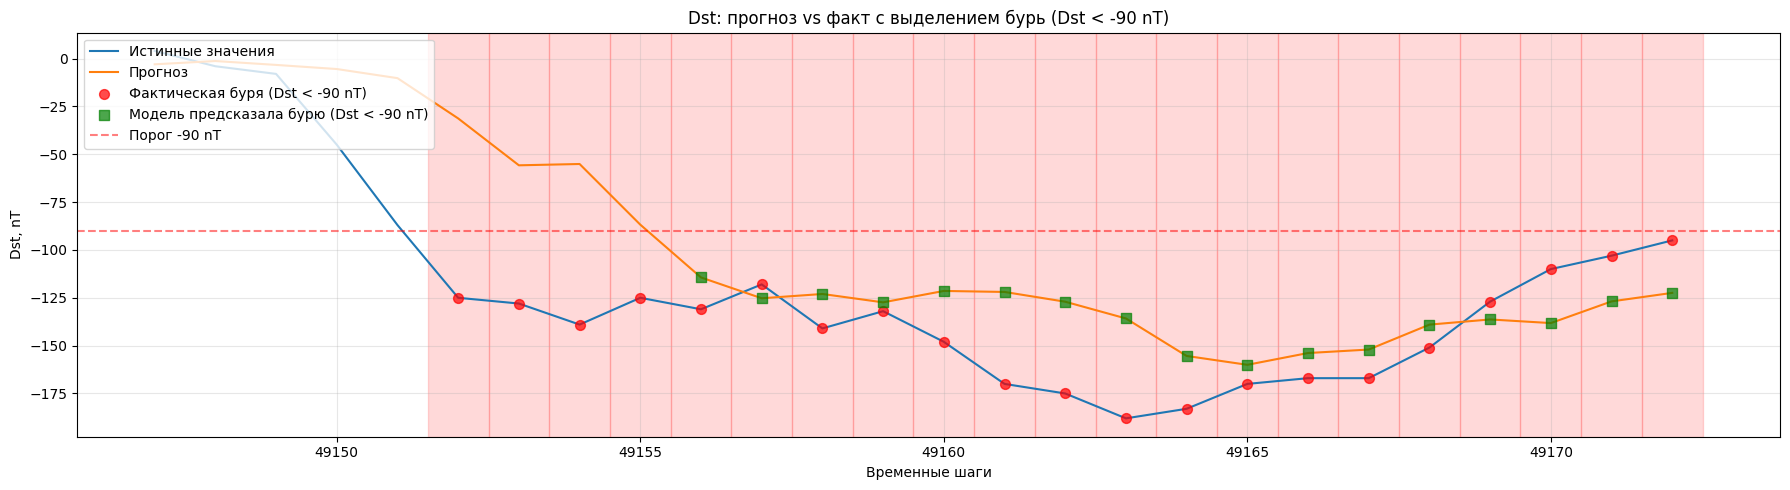

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 21
Всего моментов, когда модель предсказала бурю: 17
Precision: 1.000
Recall: 0.810
F1: 0.895


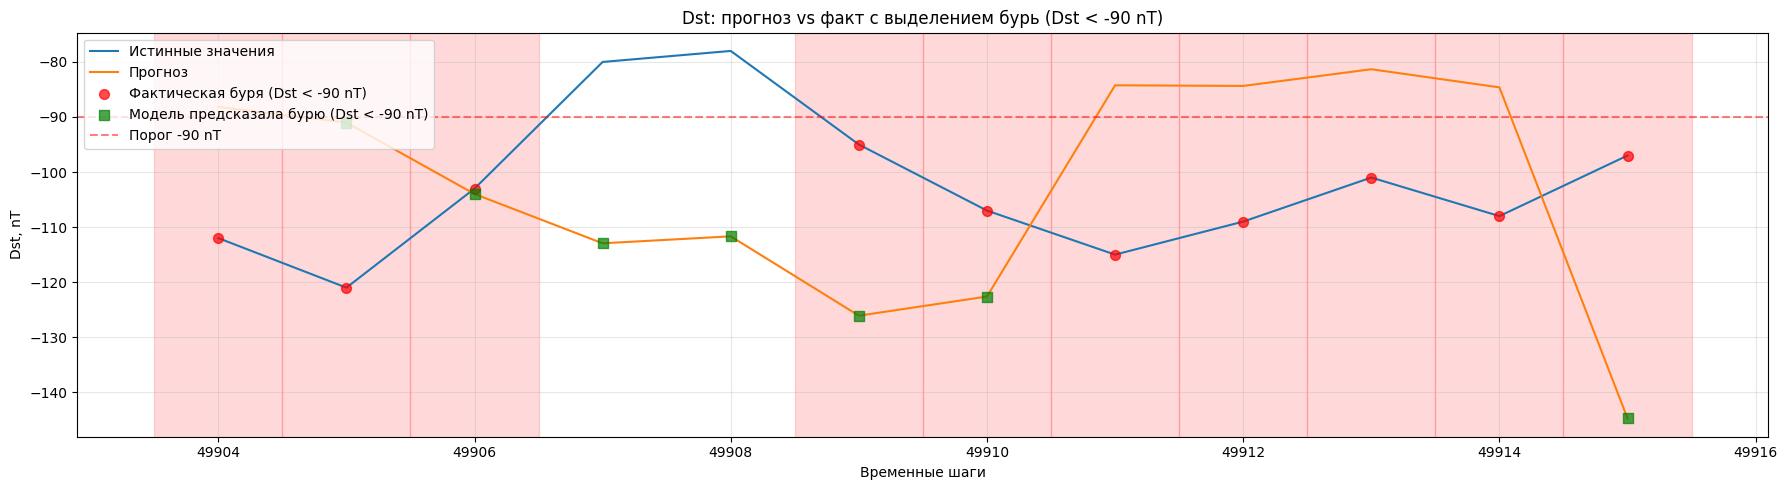

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 10
Всего моментов, когда модель предсказала бурю: 7
Precision: 0.714
Recall: 0.500
F1: 0.588


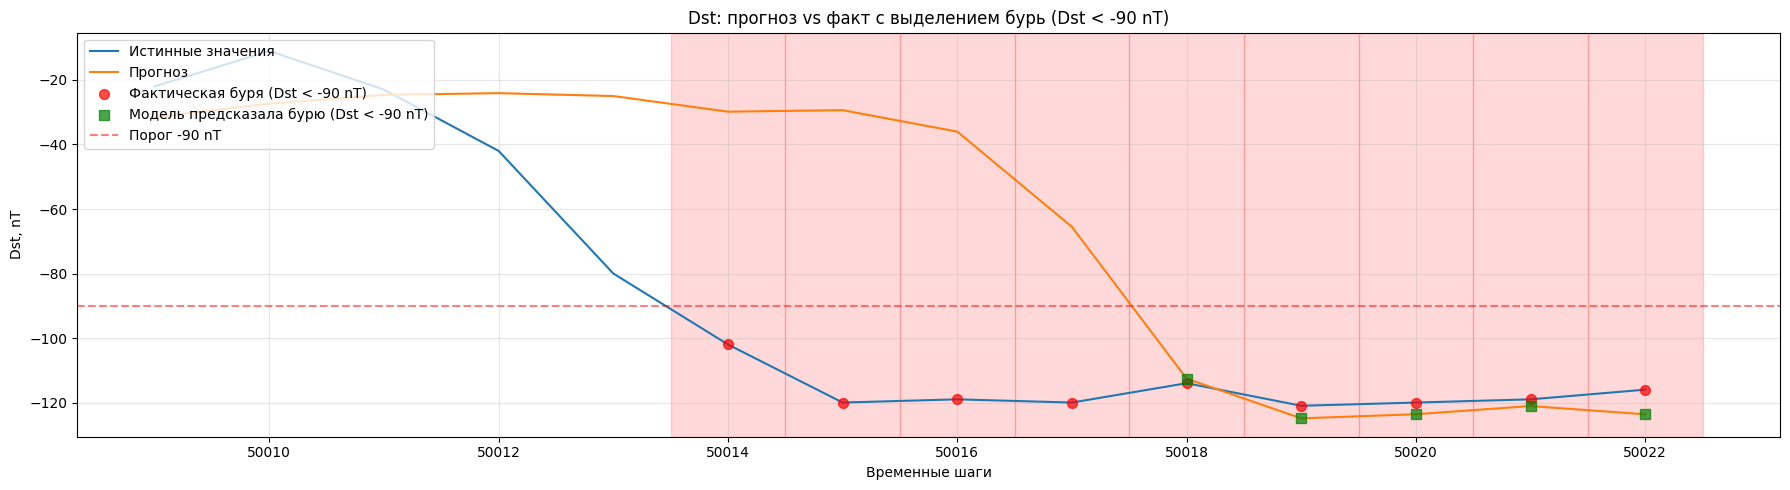

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 9
Всего моментов, когда модель предсказала бурю: 5
Precision: 1.000
Recall: 0.556
F1: 0.714


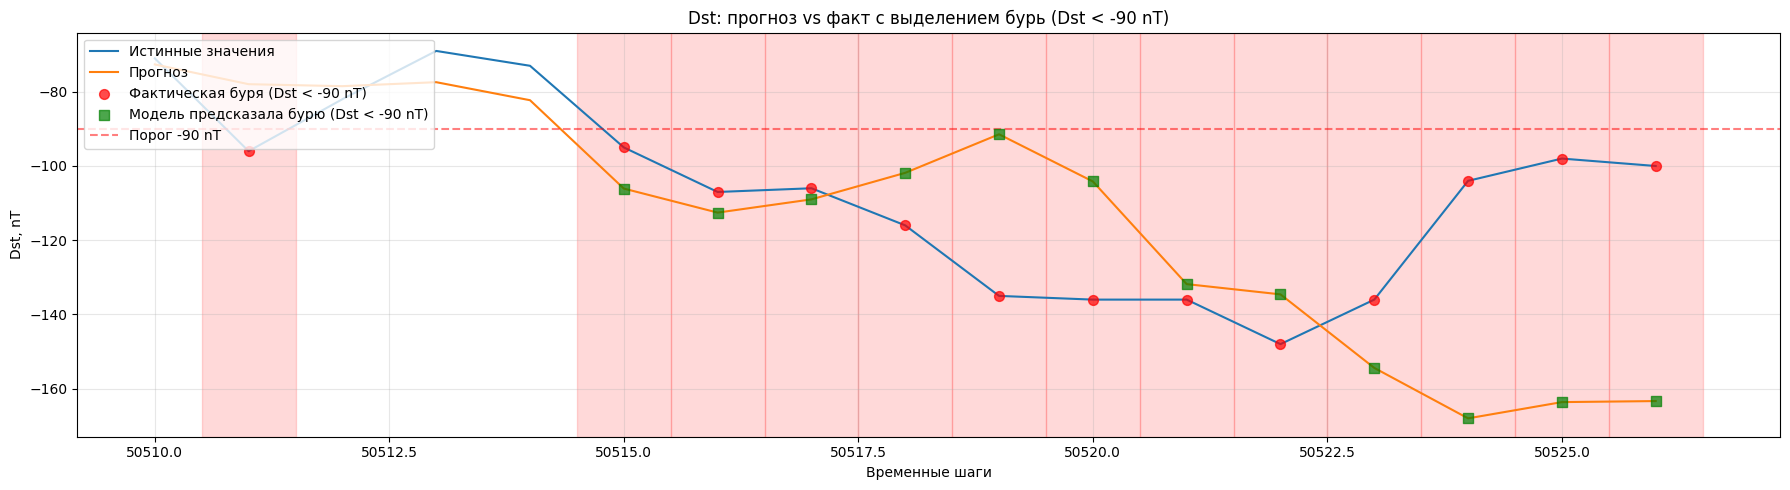

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 13
Всего моментов, когда модель предсказала бурю: 12
Precision: 1.000
Recall: 0.923
F1: 0.960


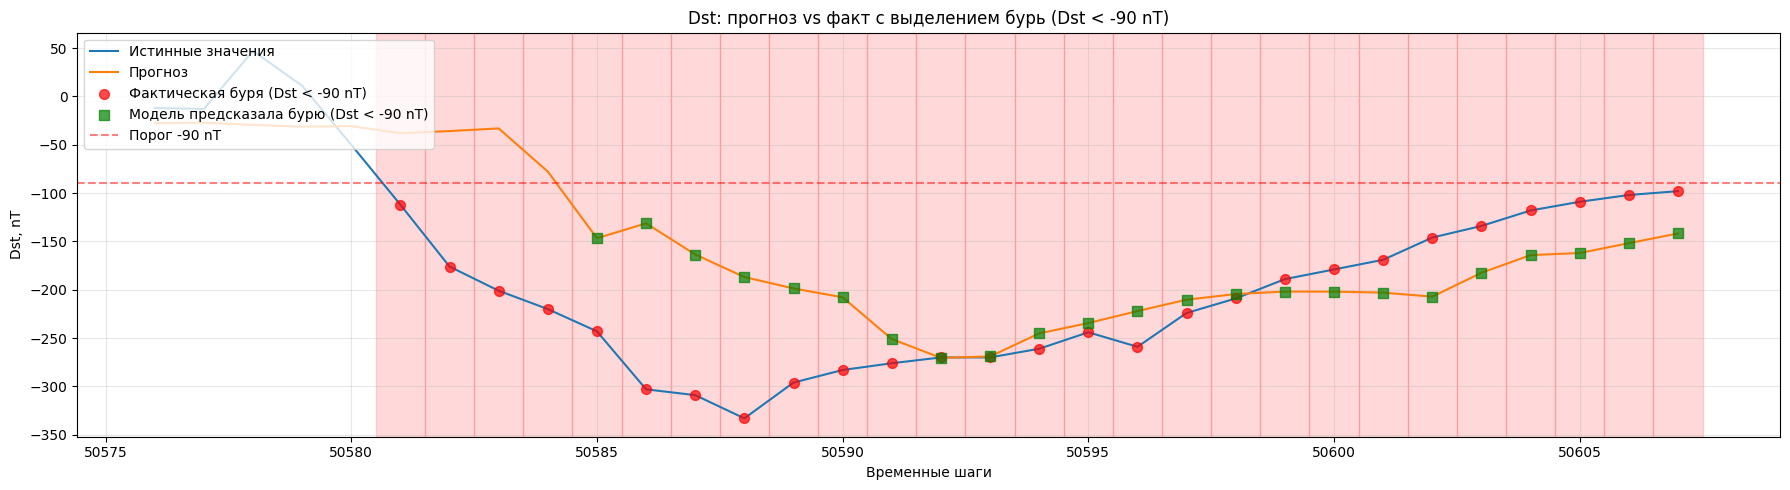

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 27
Всего моментов, когда модель предсказала бурю: 23
Precision: 1.000
Recall: 0.852
F1: 0.920


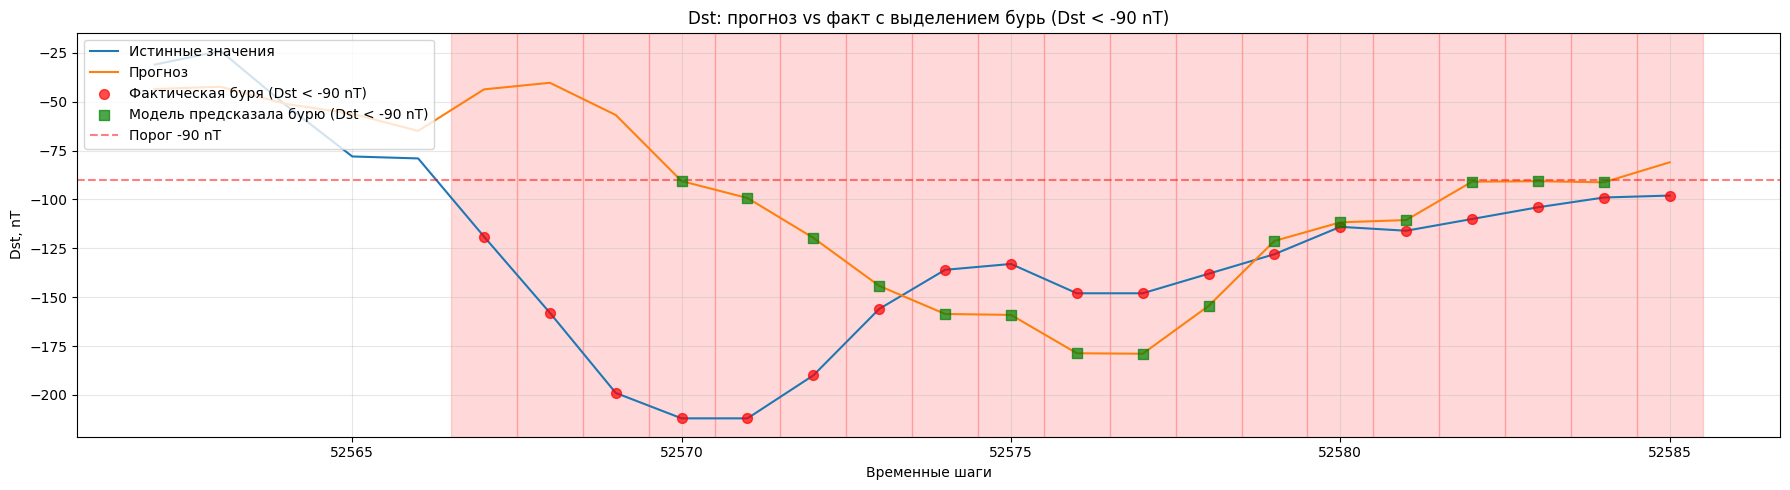

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 19
Всего моментов, когда модель предсказала бурю: 15
Precision: 1.000
Recall: 0.789
F1: 0.882


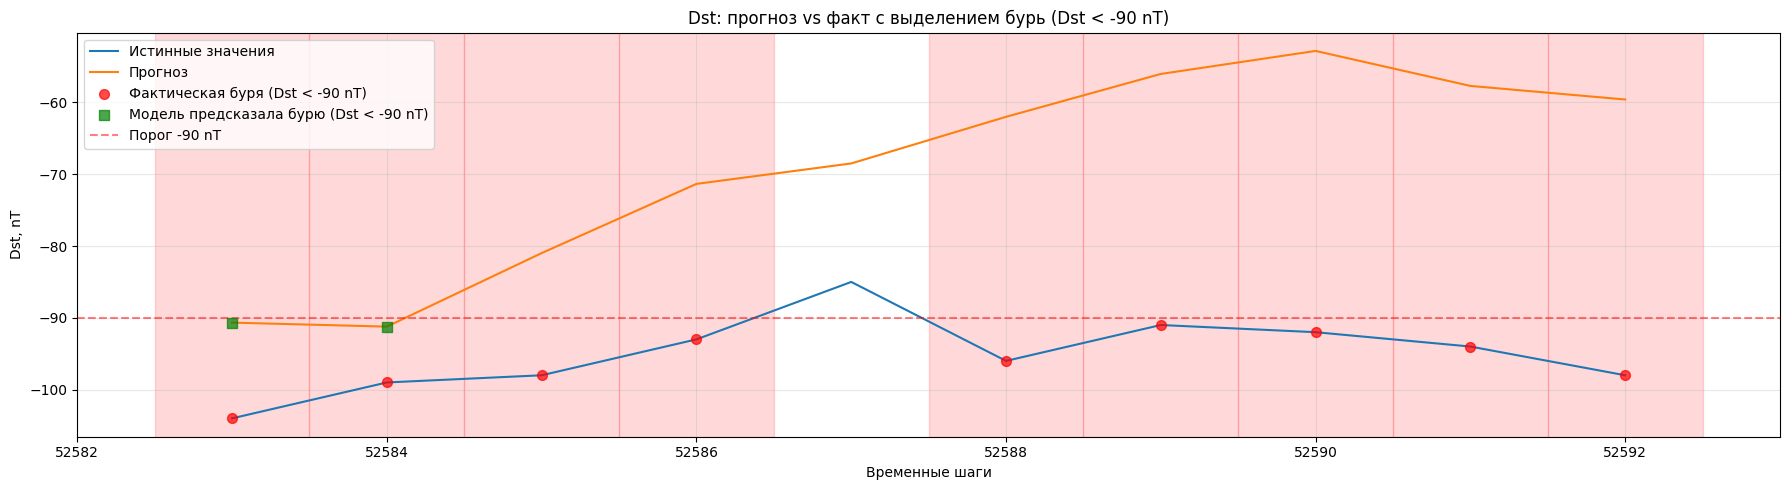

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 9
Всего моментов, когда модель предсказала бурю: 2
Precision: 1.000
Recall: 0.222
F1: 0.364


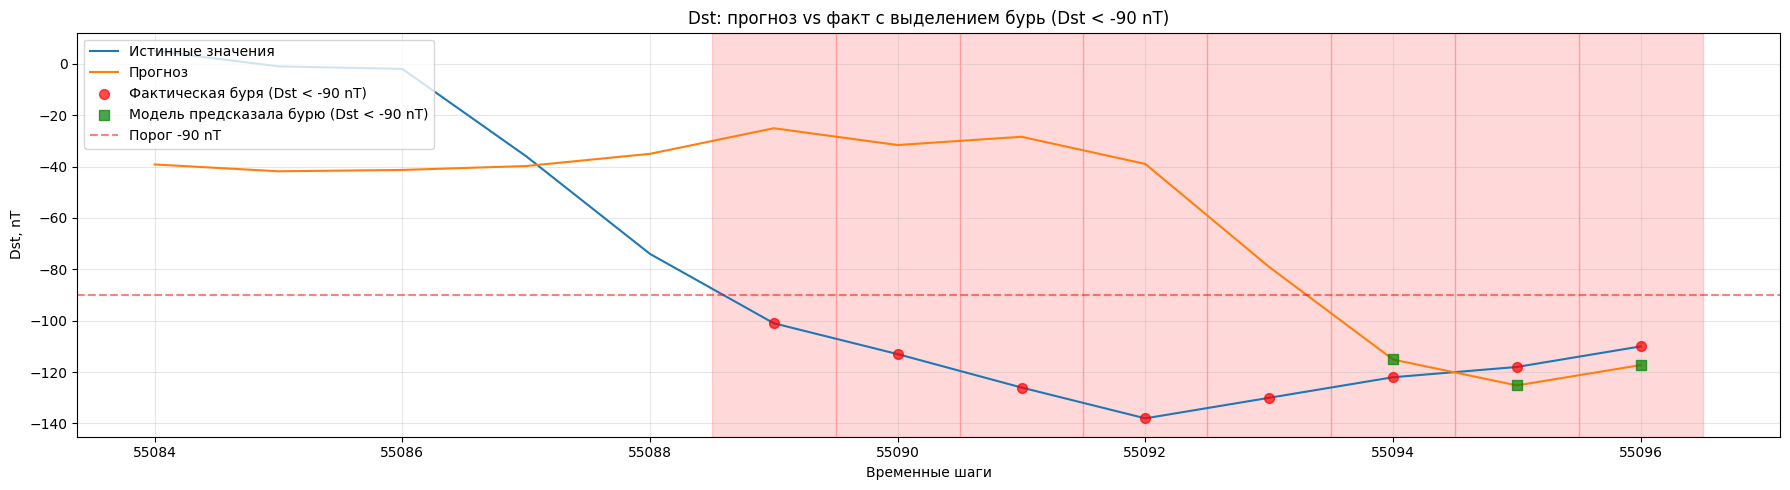

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 8
Всего моментов, когда модель предсказала бурю: 3
Precision: 1.000
Recall: 0.375
F1: 0.545


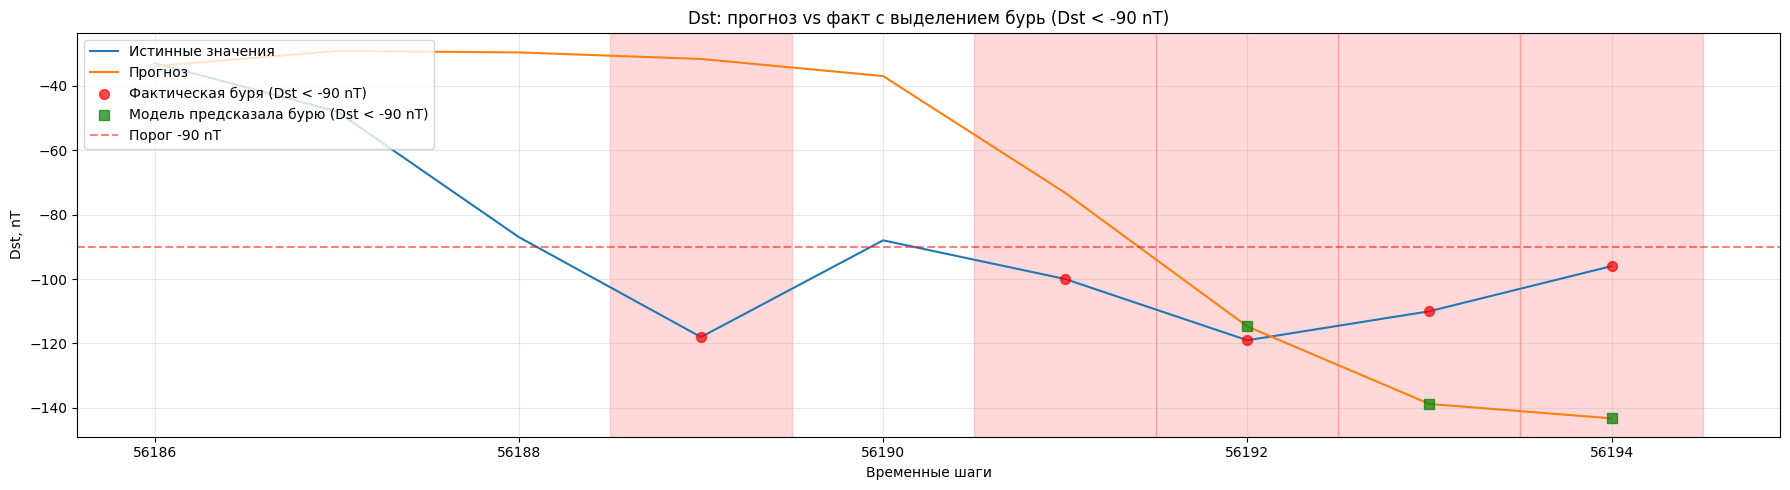

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 5
Всего моментов, когда модель предсказала бурю: 3
Precision: 1.000
Recall: 0.600
F1: 0.750


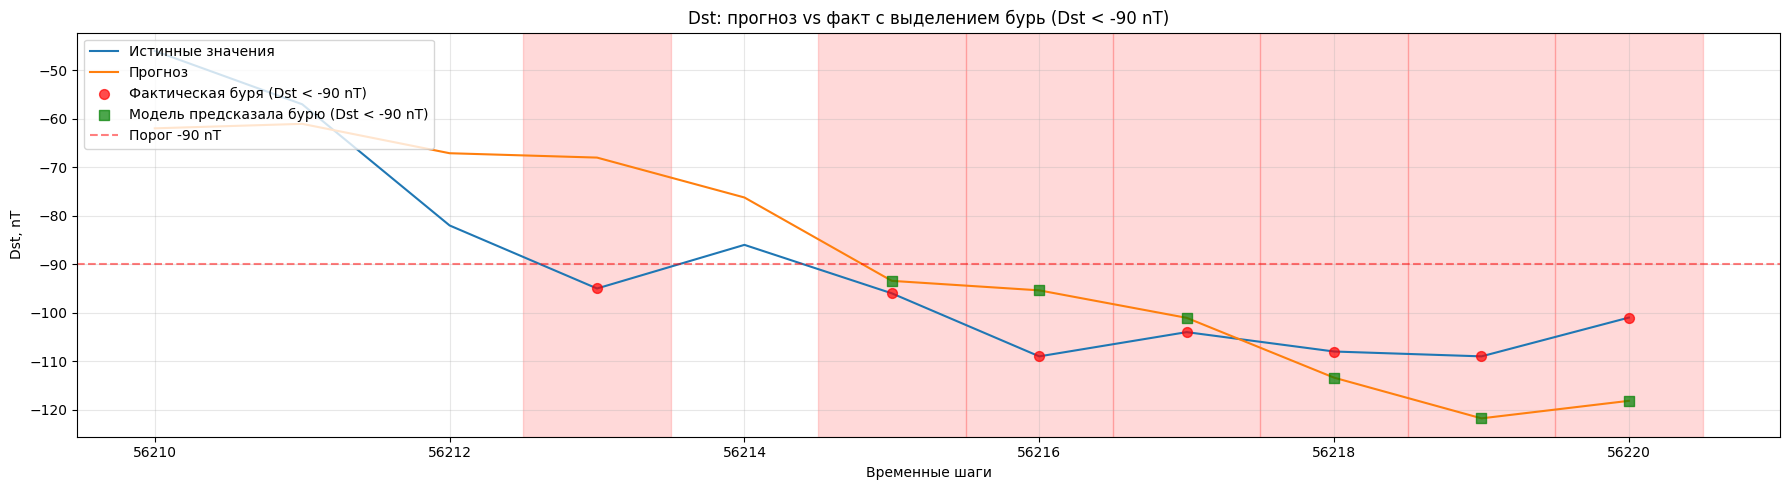

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 7
Всего моментов, когда модель предсказала бурю: 6
Precision: 1.000
Recall: 0.857
F1: 0.923


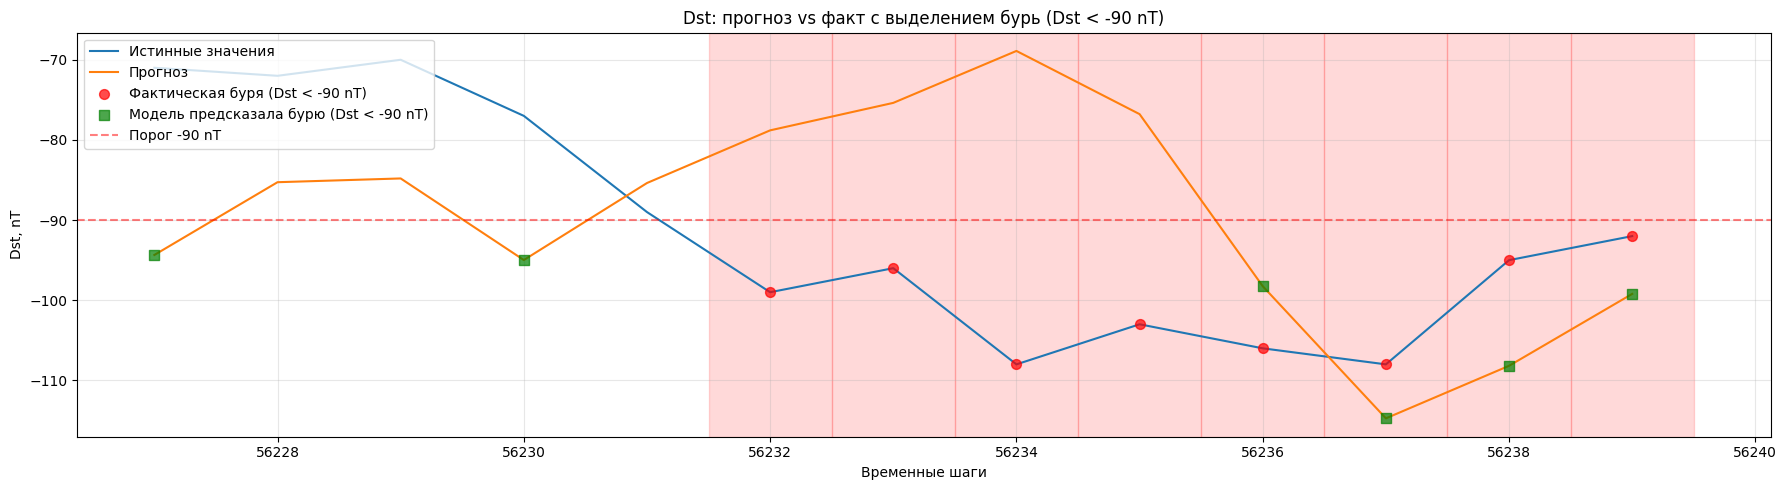

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 8
Всего моментов, когда модель предсказала бурю: 6
Precision: 0.667
Recall: 0.500
F1: 0.571


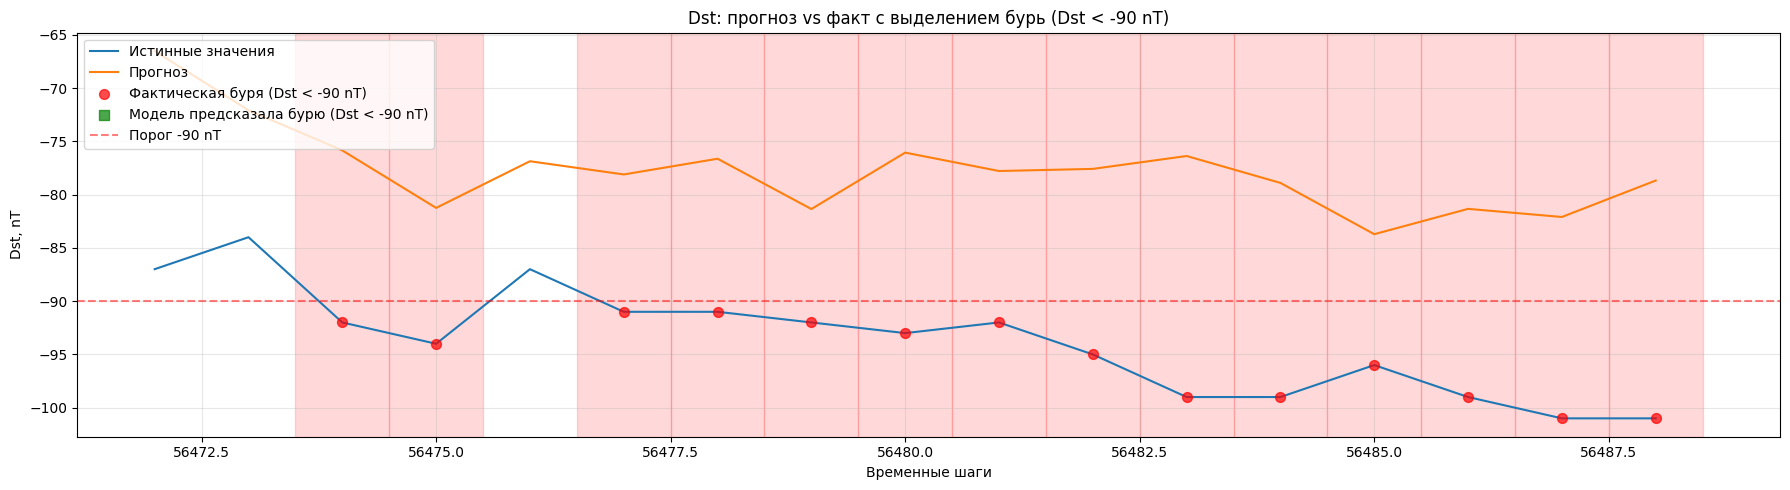

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 14
Всего моментов, когда модель предсказала бурю: 0
Precision: 0.000
Recall: 0.000


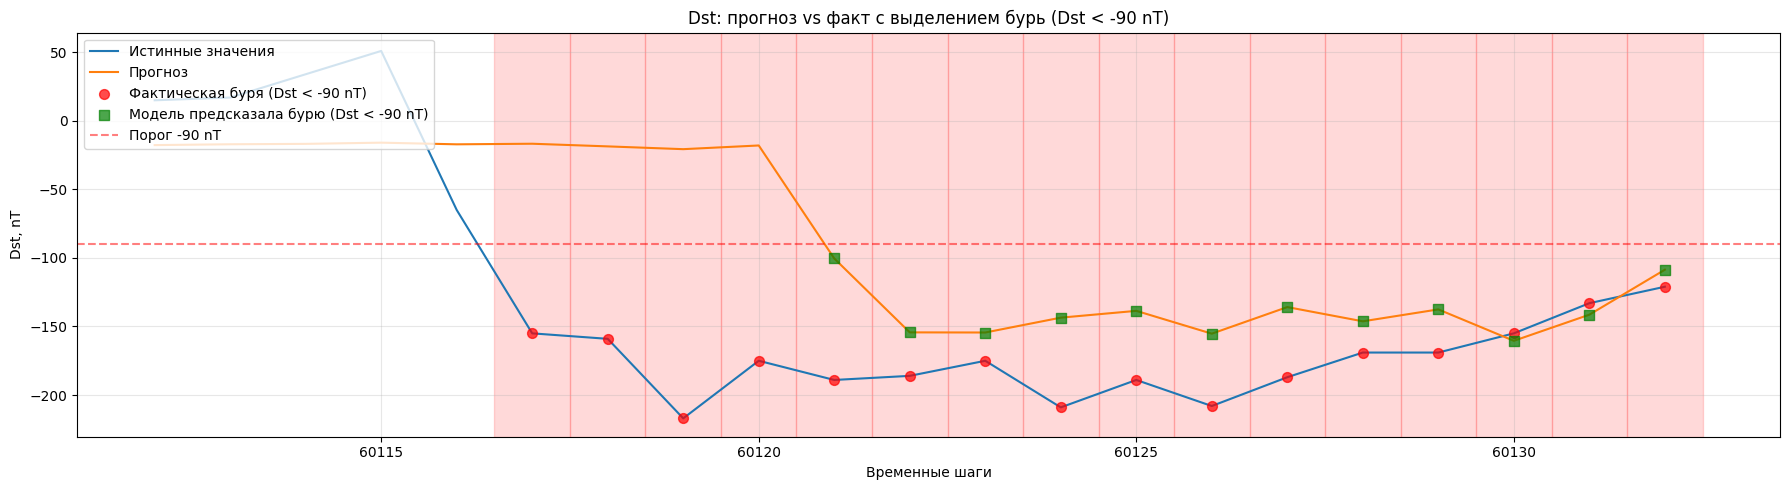

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 16
Всего моментов, когда модель предсказала бурю: 12
Precision: 1.000
Recall: 0.750
F1: 0.857


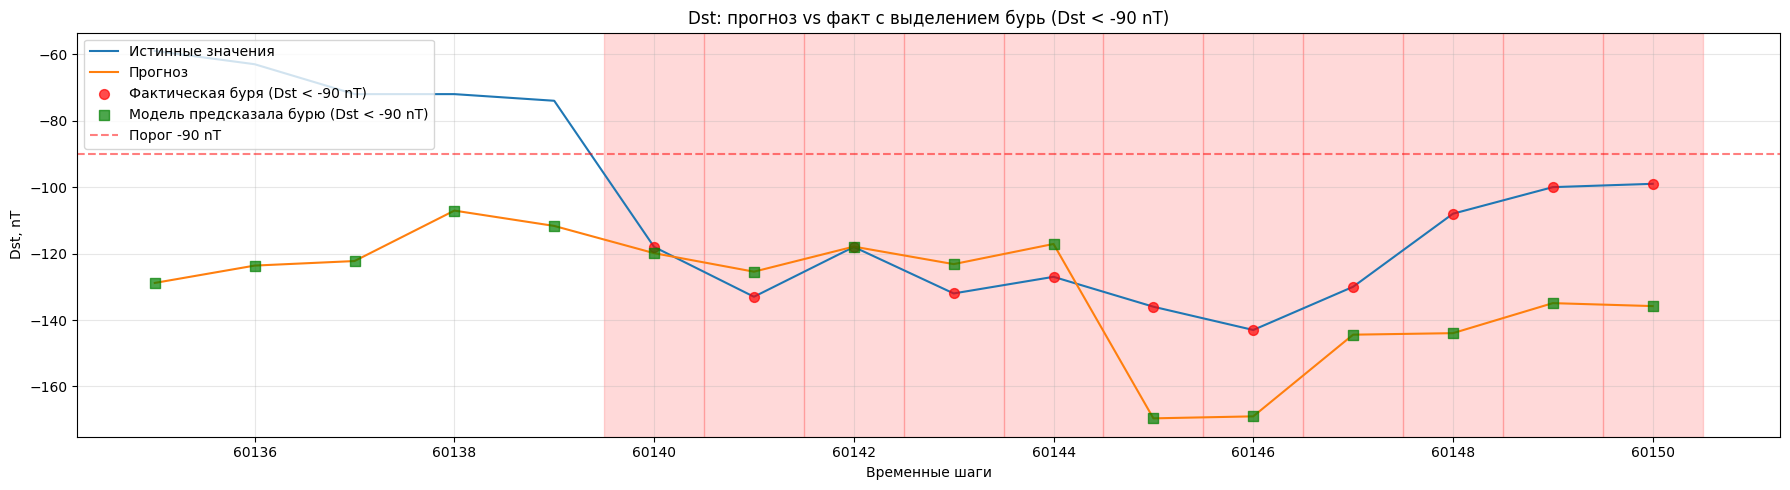

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 11
Всего моментов, когда модель предсказала бурю: 16
Precision: 0.688
Recall: 1.000
F1: 0.815

Средний F1 по всем бурям: 0.739


In [7]:
result = model(dataset_2019_2025, visualize=True, prefix="2019-2025")

In [8]:
def dst_to_class(dst):
    if isinstance(dst, (int, float)):
        if dst > -50:
            return 0
        elif dst > -100:
            return 1
        elif dst > -200:
            return 2
        else:
            return 3
    
    dst = np.array(dst)
    classes = np.zeros_like(dst, dtype=int)
    classes[dst > -50] = 0
    classes[(dst <= -50) & (dst > -100)] = 1
    classes[(dst <= -100) & (dst > -200)] = 2
    classes[dst <= -200] = 3
    
    return classes

In [9]:
dst_labels = result["dst_labels"]
dst_preds = result["dst_preds"]
ae_labels = result["ae_labels"]
ae_preds = result["ae_preds"]

cr = classification_report(dst_to_class(dst_labels), dst_to_class(dst_preds))
print(cr)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     59485
           1       0.52      0.47      0.49      1559
           2       0.47      0.59      0.53       224
           3       0.80      0.43      0.56        46

    accuracy                           0.97     61314
   macro avg       0.69      0.62      0.64     61314
weighted avg       0.97      0.97      0.97     61314



### Dst-index (индекс кольцевого тока)
Отражает глобальное возмущение геомагнитного поля, вызванное магнитными бурями

In [10]:
import scipy.stats as stats

errors = dst_labels - dst_preds
error_std = np.std(errors)
error_mean = np.mean(errors)
alpha = 0.95
z = stats.norm.ppf((1 + alpha) / 2)

ci_lower = dst_preds + (error_mean - z * error_std)
ci_upper = dst_preds + (error_mean + z * error_std)

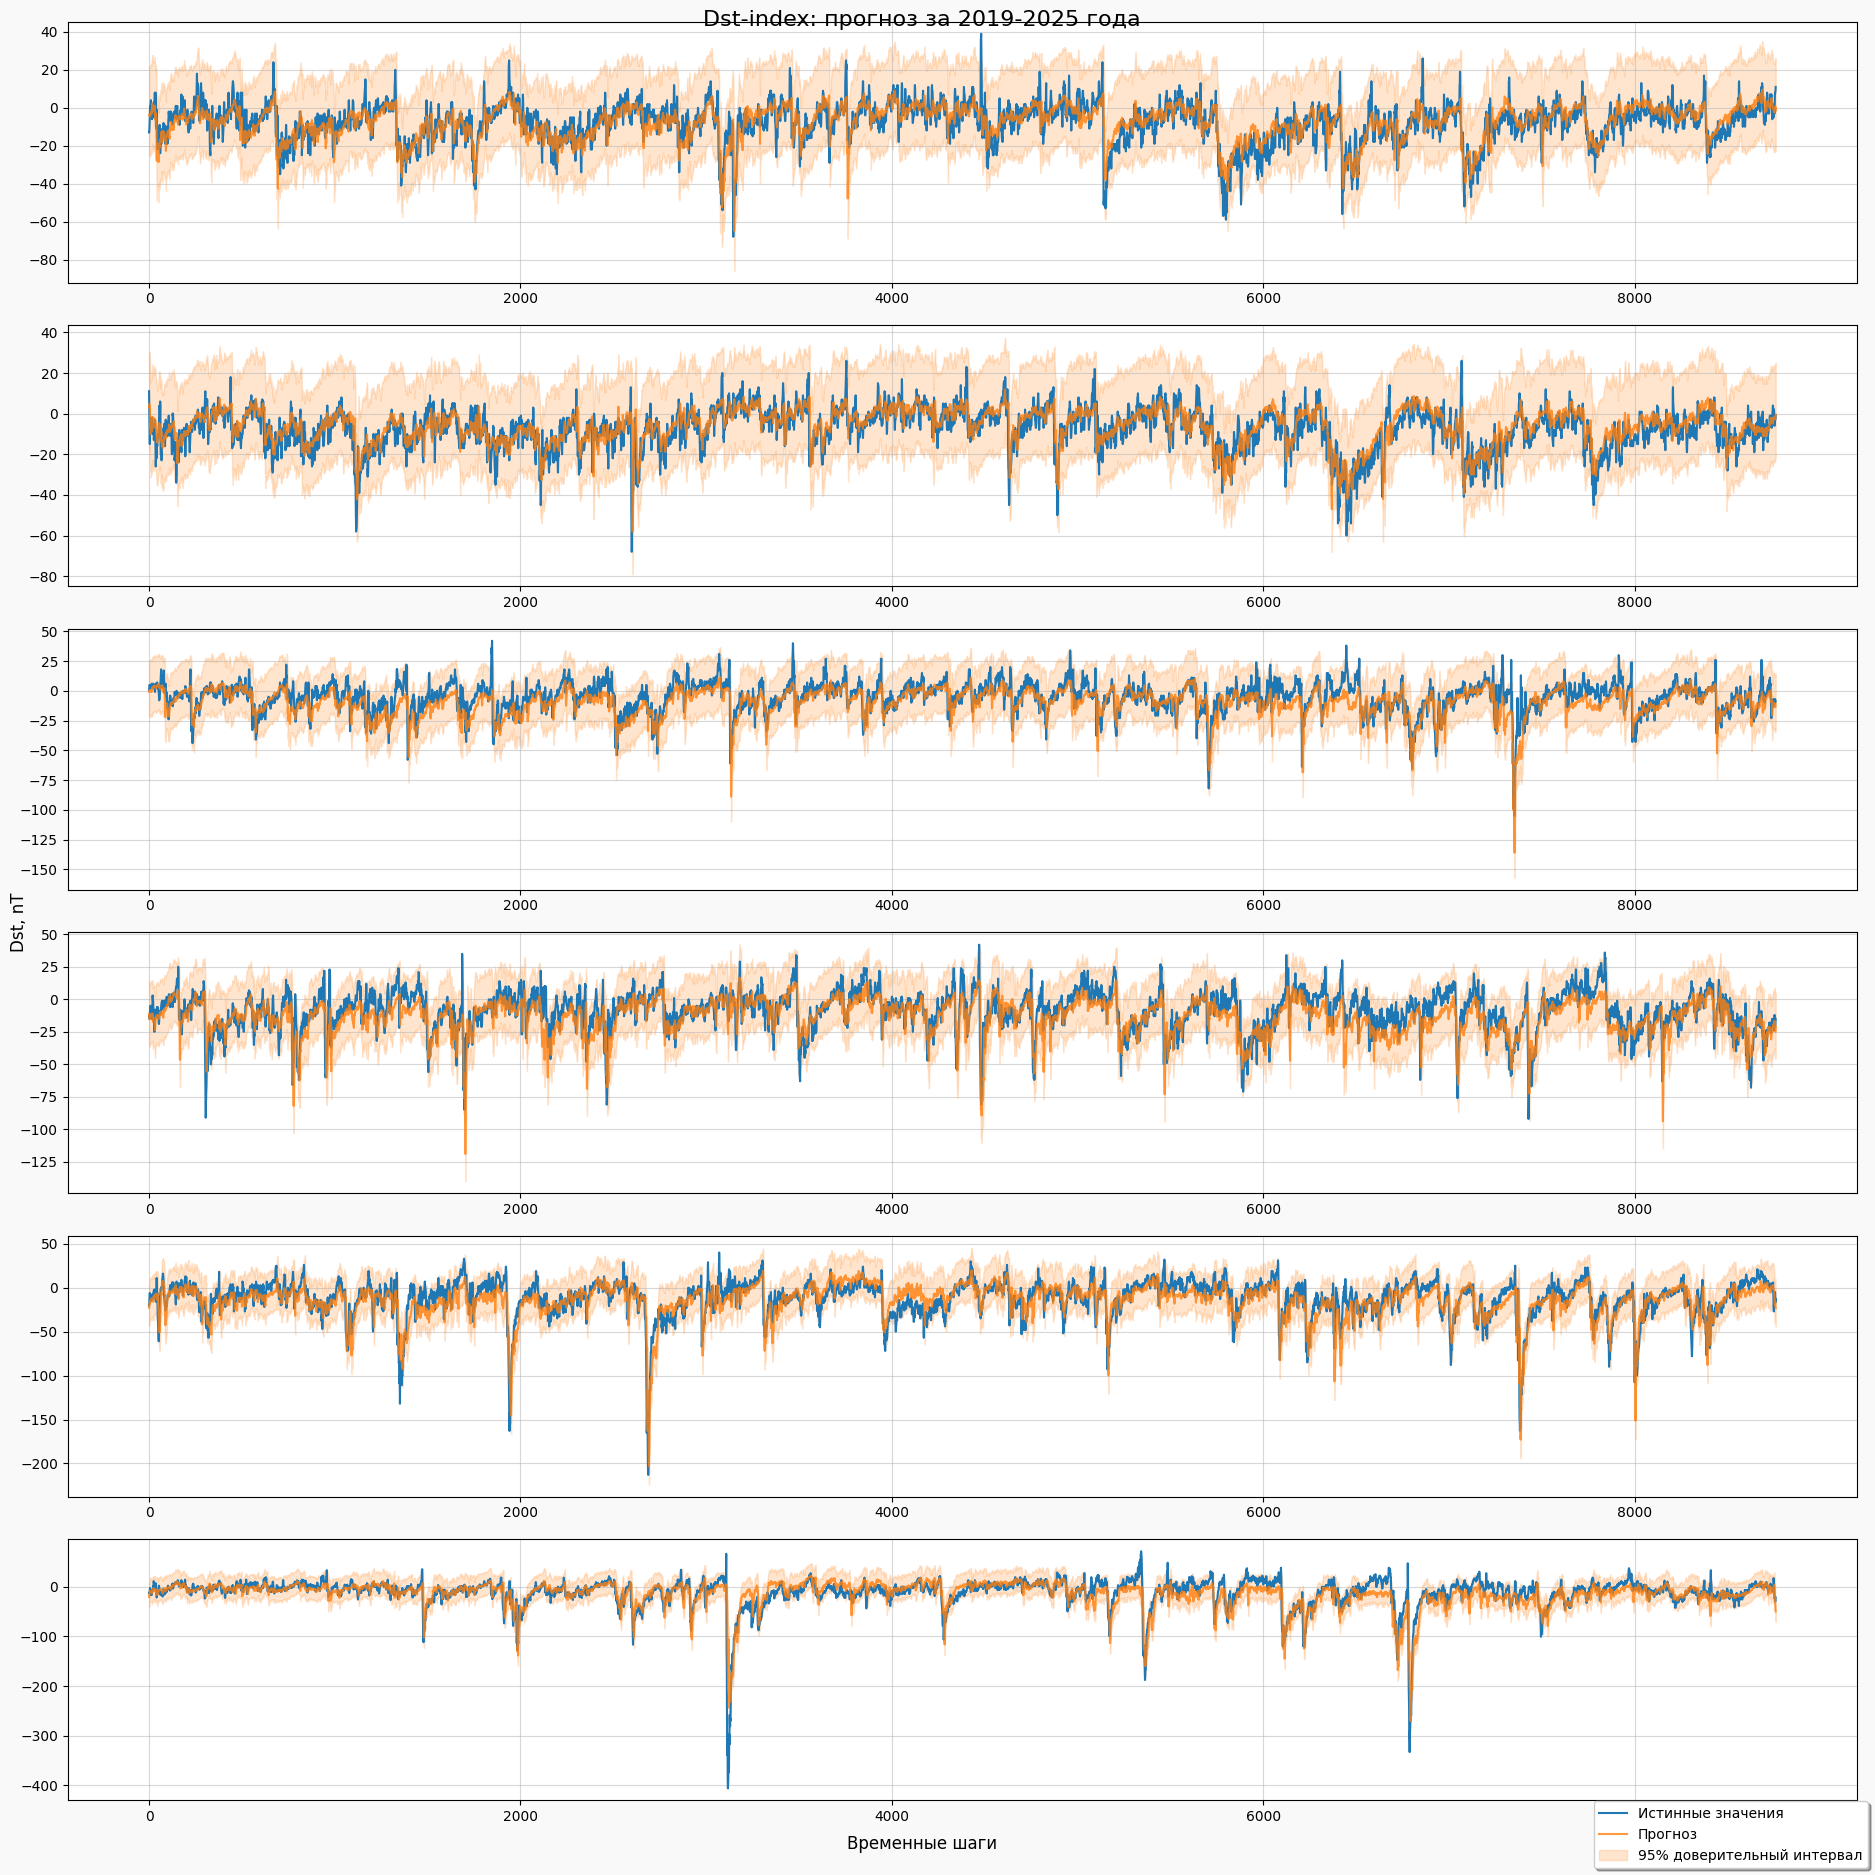

In [11]:
fig, axes = plt.subplots(6, 1, figsize=(19, 19))
axes = axes.flatten()
for idx, x in enumerate([(0, 8760), (8760, 17520), (17520, 26280,), (26280, 35040), (35040, 43800), (43800, 52560)]):
    start, end = x
    axes[idx].plot(dst_labels[start:end], label='Истинные значения')
    axes[idx].plot(dst_preds[start:end], label='Прогноз', alpha=0.8, )
    axes[idx].fill_between(
        range(end - start),
        ci_lower[start:end],
        ci_upper[start:end],
        color='#ff7f0e',
        alpha=0.2,
        label=f'{int(alpha*100)}% доверительный интервал'
    )
  
    axes[idx].grid(alpha=0.5)

fig.suptitle('Dst-index: прогноз за 2019-2025 года', fontsize=16)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', fontsize=10, frameon=True, fancybox=True, shadow=True)
fig.supxlabel('Временные шаги', fontsize=12)
fig.supylabel('Dst, nT', fontsize=12)
fig.patch.set_facecolor('#f9f9f9')
plt.tight_layout()
plt.show()

### AE-index (индекс авроральной активности)
Отражает уровень магнитных возмущений в полярных областях, связанных с авроральными электроджетами

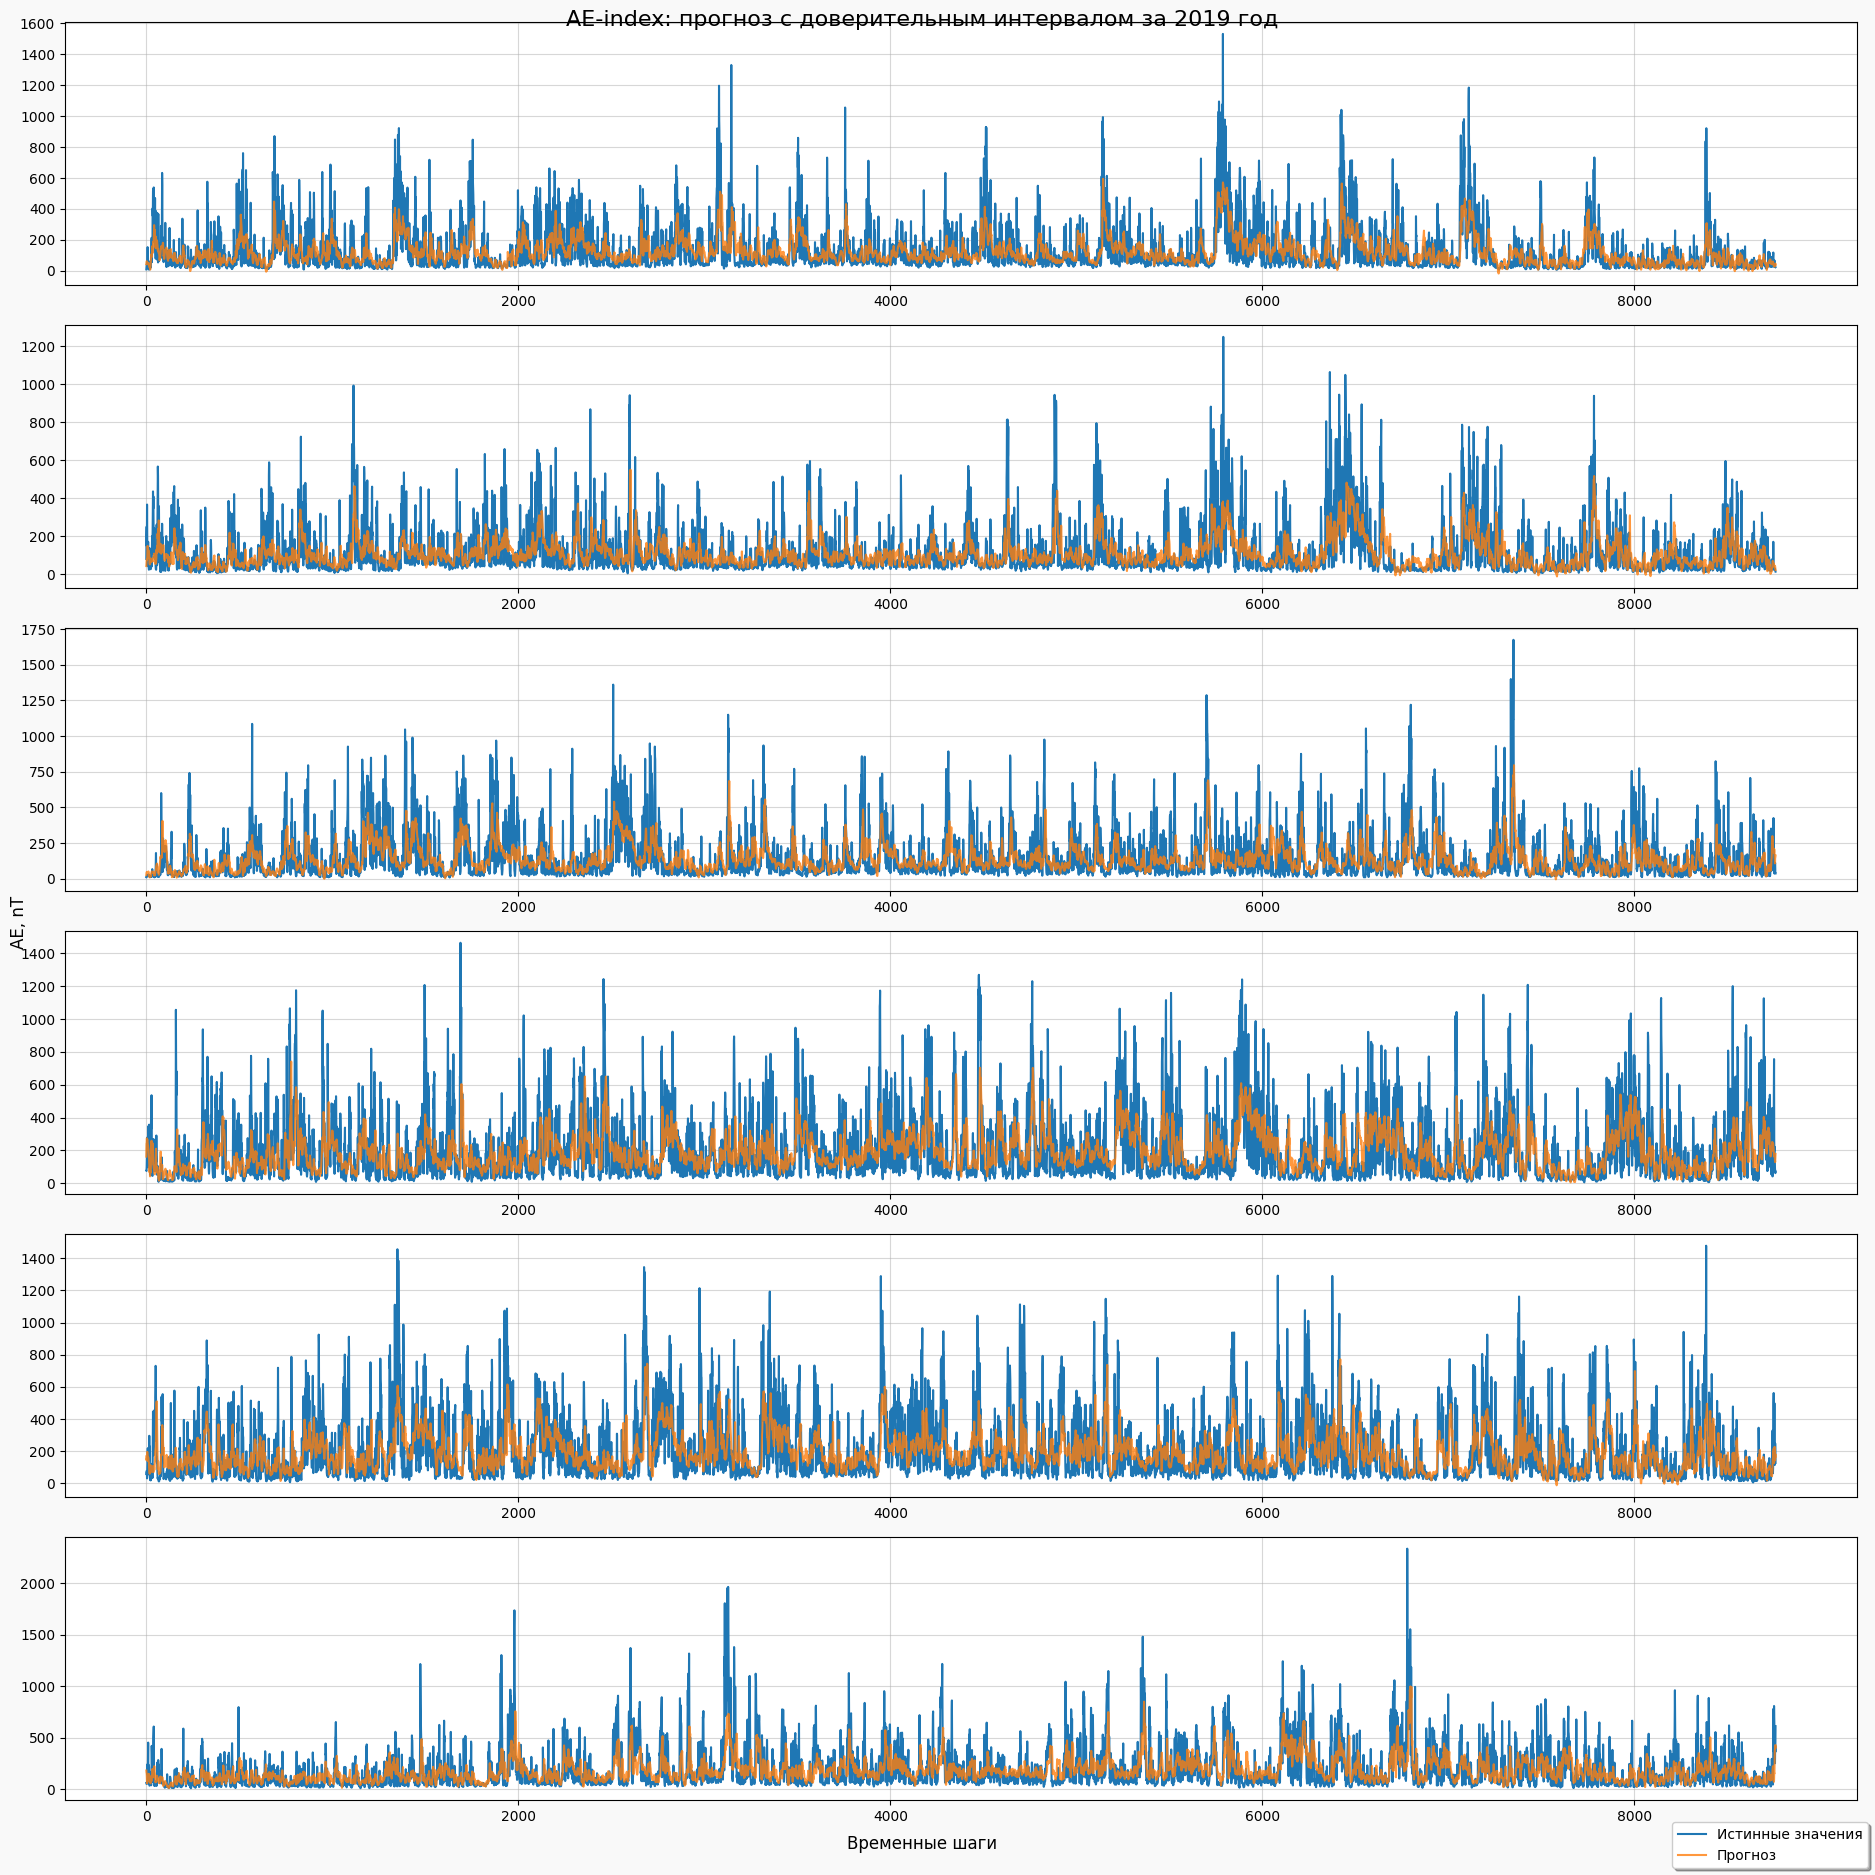

In [12]:
fig, axes = plt.subplots(6, 1, figsize=(19, 19))
axes = axes.flatten()
for idx, x in enumerate([(0, 8760), (8760, 17520), (17520, 26280,), (26280, 35040), (35040, 43800), (43800, 52560)]):
    start, end = x
    axes[idx].plot(ae_labels[start:end], label='Истинные значения')
    axes[idx].plot(ae_preds[start:end], label='Прогноз', alpha=0.8, )

    axes[idx].grid(alpha=0.5)

fig.suptitle('AE-index: прогноз с доверительным интервалом за 2019 год', fontsize=16)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', fontsize=10, frameon=True, fancybox=True, shadow=True)
fig.supxlabel('Временные шаги', fontsize=12)
fig.supylabel('AE, nT', fontsize=12)
fig.patch.set_facecolor('#f9f9f9')
plt.tight_layout()
plt.show()

In [ ]:
# !wget -P data/omni_actual https://spdf.gsfc.nasa.gov/pub/data/omni/low_res_omni/omni2_2025.dat

In [13]:
predict = model.predict_next("data/omni_actual/omni2_2026.dat")

Последний найденный индекс без пропусков: 3287, 136-й день с начала года
ПРОГНОЗ НА СЛЕДУЮЩИЕ 6 ЧАСОВ:
t+1: Dst = -26.05 nT, AE = 331.50 nT
t+2: Dst = -24.00 nT, AE = 290.74 nT
t+3: Dst = -23.04 nT, AE = 285.16 nT
t+4: Dst = -19.24 nT, AE = 246.92 nT
t+5: Dst = -16.61 nT, AE = 220.00 nT
t+6: Dst = -13.92 nT, AE = 227.55 nT


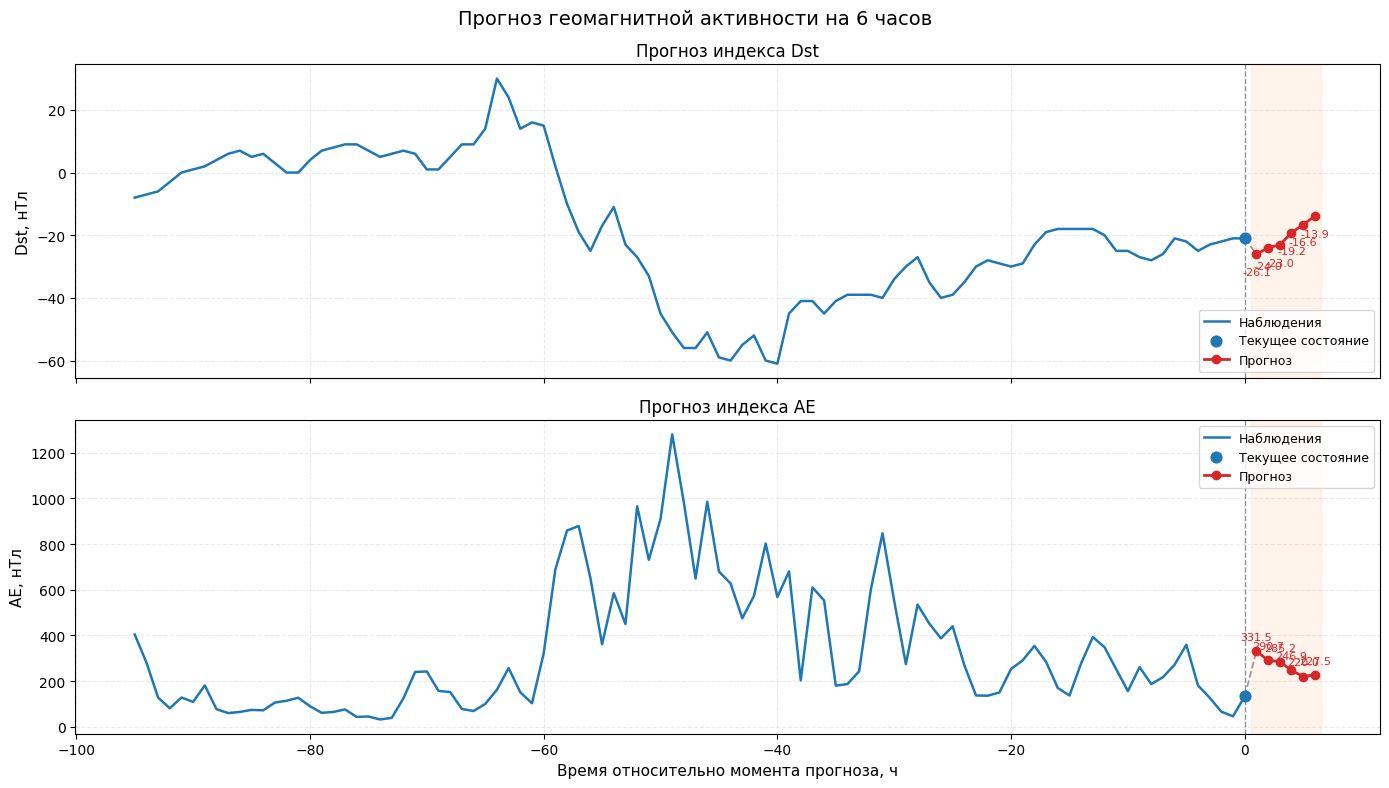

In [14]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
history_dst = predict["history_dst"]
history_ae = predict["history_ae"]
dst_pred = predict["dst_predictions"]
ae_pred = predict["ae_predictions"]
n_history = len(history_dst)
history_hours = np.arange(-n_history + 1, 1)
forecast_hours = np.arange(1, 7)
ax1.plot(history_hours, history_dst, color="#1f77b4", linewidth=1.8, label="Наблюдения")
ax1.scatter(
    0, history_dst[-1], color="#1f77b4", s=60, zorder=5, label="Текущее состояние"
)
ax1.plot(
    [0, 1], [history_dst[-1], dst_pred[0]], "--", color="0.5", linewidth=1.3, alpha=0.8
)
ax1.plot(
    forecast_hours,
    dst_pred,
    color="#d62728",
    linewidth=2,
    marker="o",
    markersize=6,
    label="Прогноз",
)

for i, val in enumerate(dst_pred):
    ax1.annotate(
        f"{val:.1f}",
        xy=(i + 1, val),
        xytext=(0, 8 if val >= 0 else -15),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        color="#d62728",
    )
ax1.axvline(0, color="black", linestyle="--", alpha=0.4, linewidth=1)
ax1.axvspan(0.5, 6.5, alpha=0.08, color="#ff7f0e")
ax1.set_ylabel("Dst, нТл", fontsize=11)
ax1.set_title("Прогноз индекса Dst", fontsize=12, fontweight="medium")
ax1.grid(True, alpha=0.25, linestyle="--")
ax1.legend(loc="lower right", fontsize=9)
ax2.plot(history_hours, history_ae, color="#1f77b4", linewidth=1.8, label="Наблюдения")
ax2.scatter(0, history_ae[-1], color="#1f77b4", s=60, zorder=5, label="Текущее состояние")
ax2.plot([0, 1], [history_ae[-1], ae_pred[0]], "--", color="0.5", linewidth=1.3, alpha=0.8)
ax2.plot(
    forecast_hours,
    ae_pred,
    color="#d62728",
    linewidth=2,
    marker="o",
    markersize=6,
    label="Прогноз",
)

for i, val in enumerate(ae_pred):
    ax2.annotate(
        f"{val:.1f}",
        xy=(i + 1, val),
        xytext=(0, 8 if val >= 0 else -15),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        color="#d62728",
    )
ax2.axvline(0, color="black", linestyle="--", alpha=0.4, linewidth=1)
ax2.axvspan(0.5, 6.5, alpha=0.08, color="#ff7f0e")
ax2.set_xlabel("Время относительно момента прогноза, ч", fontsize=11)
ax2.set_ylabel("AE, нТл", fontsize=11)
ax2.set_title("Прогноз индекса AE", fontsize=12, fontweight="medium")
ax2.grid(True, alpha=0.25, linestyle="--")
ax2.legend(loc="upper right", fontsize=9)
plt.suptitle("Прогноз геомагнитной активности на 6 часов", fontsize=14, fontweight="medium")
plt.tight_layout()
plt.show()